<a href="https://colab.research.google.com/github/athifashihab/FDSProject/blob/main/Khulood(25200155)_Daily_ARIMA_SARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Piece 1 — Load dataset and prepare the daily energy series

Daily dataset shape: (366, 1)
Missing values: 0
              energy_kwh
timestamp               
2018-01-01  5.587442e+08
2018-01-02  5.498893e+08
2018-01-03  5.416369e+08
2018-01-04  4.903382e+08
2018-01-05  4.437662e+08
2018-01-06  4.610663e+08
2018-01-07  5.798194e+08
2018-01-08  5.404069e+08
2018-01-09  5.544997e+08
2018-01-10  6.180765e+08


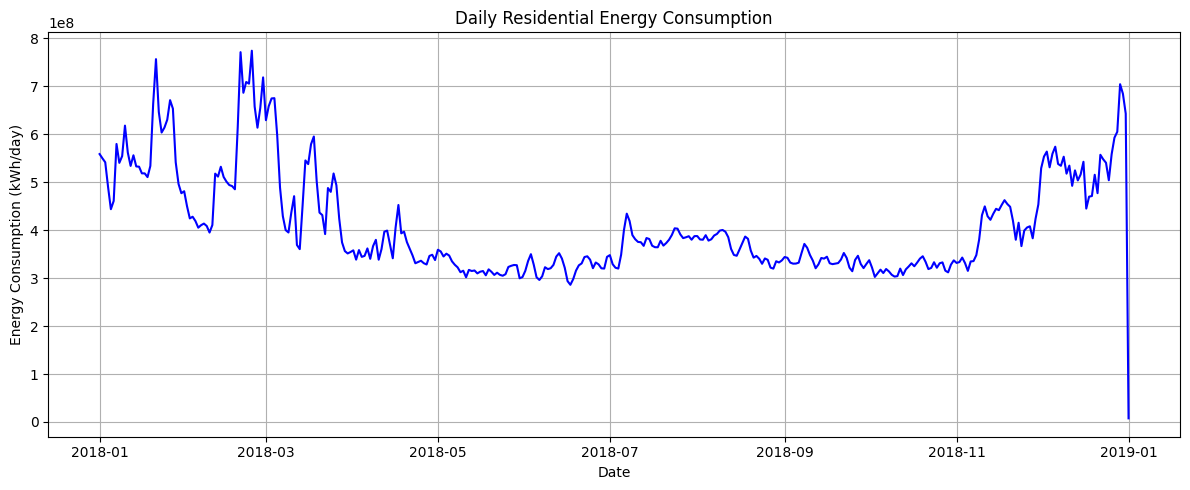

Saved: daily_energy_series.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

path = "/content/drive/MyDrive/new_dataset"
df = pd.read_csv(f"{path}/up00-ca-single-family_detached.csv")

# Keep only the columns we need
df = df[["timestamp", "out.site_energy.total.energy_consumption.kwh"]].copy()
df.columns = ["timestamp", "energy_kwh"]

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")
df.set_index("timestamp", inplace=True)

# Fill any missing values in the raw series
df["energy_kwh"] = df["energy_kwh"].interpolate(method="linear")

# Resample 15-min → daily (sum all intervals within each day)
daily_df = df.resample("D").sum()
daily_df["energy_kwh"] = daily_df["energy_kwh"].interpolate(method="linear")

print("Daily dataset shape:", daily_df.shape)
print("Missing values:", daily_df.isnull().sum().values[0])
print(daily_df.head(10))

# Plot the full daily series
plt.figure()
plt.plot(daily_df.index, daily_df["energy_kwh"], color="blue")
plt.title("Daily Residential Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (kWh/day)")
plt.tight_layout()
plt.show()

daily_df.to_csv("daily_energy_series.csv")
print("Saved: daily_energy_series.csv")


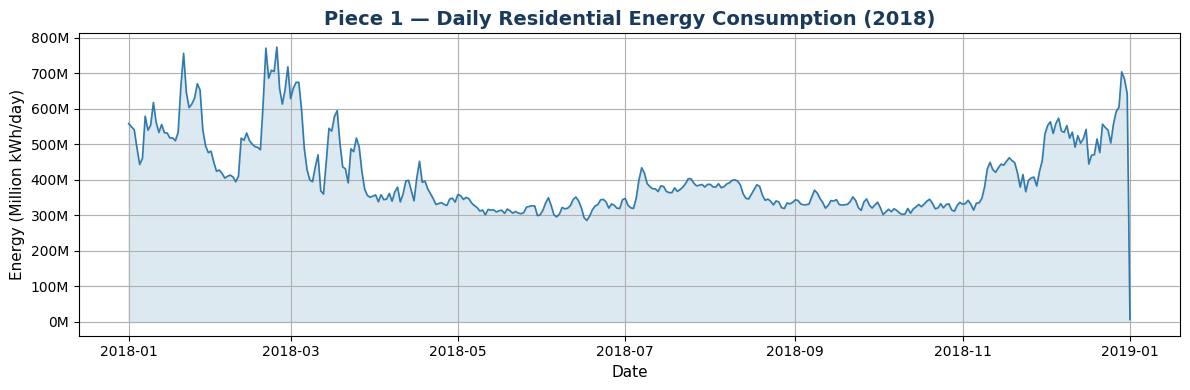

Saved: p1_daily_series.png


In [ ]:

# ── Save Piece 1 chart ──────────────────────────────────────────────────────
plt.figure(figsize=(12, 4))
plt.plot(daily_df.index, daily_df['energy_kwh']/1e6, color='#1E6FA6', linewidth=1.2, alpha=0.9)
plt.fill_between(daily_df.index, daily_df['energy_kwh']/1e6, alpha=0.15, color='#1E6FA6')
plt.title('Piece 1 — Daily Residential Energy Consumption (2018)', fontsize=14, fontweight='bold', color='#1A3A5C')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Energy (Million kWh/day)', fontsize=11)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
plt.tight_layout()
plt.savefig('p1_daily_series.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: p1_daily_series.png")


## Piece 2 — Temporal pattern analysis and peak-day identification

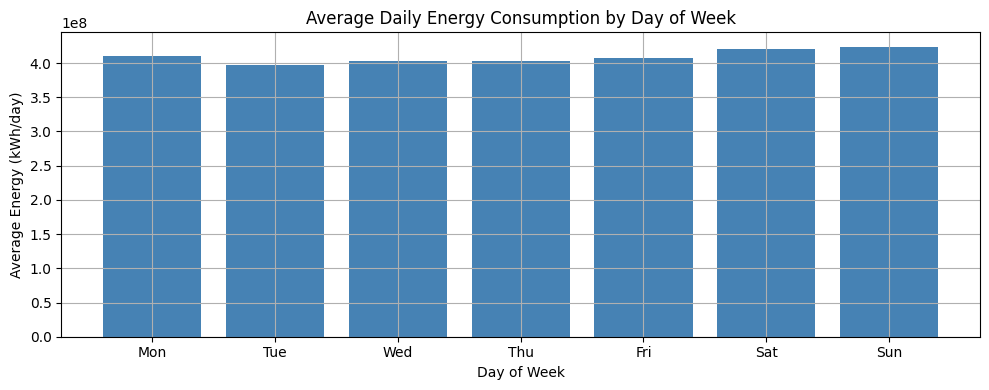

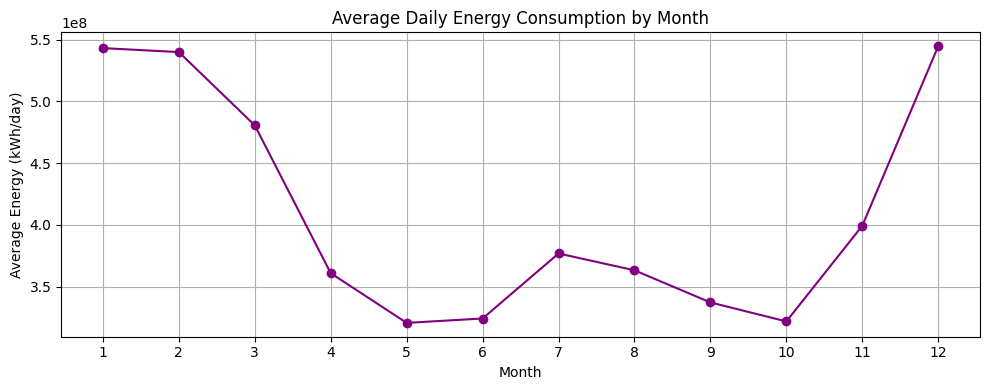

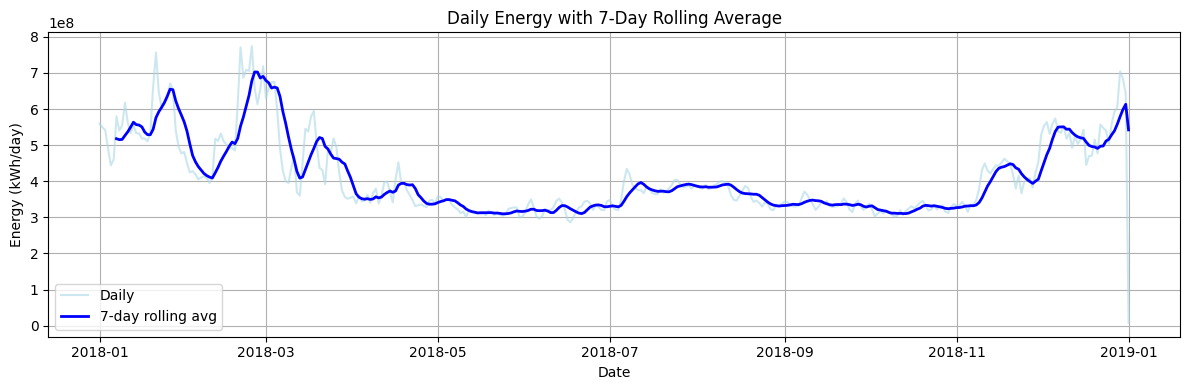

Top 3 peak days of week: ['Sun', 'Sat', 'Mon']
Day-of-week integers: [0, 5, 6]


In [ ]:
# Add time-based features
daily_df["day_of_week"] = daily_df.index.dayofweek
daily_df["month"]       = daily_df.index.month
daily_df["week"]        = daily_df.index.isocalendar().week.astype(int)

day_map = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
daily_df["day_name"] = daily_df["day_of_week"].map(day_map)

# Average consumption by day of week
daily_dow_pattern = daily_df.groupby("day_name")["energy_kwh"].mean()
daily_dow_pattern = daily_dow_pattern.reindex(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])

plt.figure(figsize=(10, 4))
plt.bar(daily_dow_pattern.index, daily_dow_pattern.values, color="steelblue")
plt.title("Average Daily Energy Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Energy (kWh/day)")
plt.tight_layout()
plt.show()

# Average consumption by month
monthly_pattern = daily_df.groupby("month")["energy_kwh"].mean()

plt.figure(figsize=(10, 4))
plt.plot(monthly_pattern.index, monthly_pattern.values, marker="o", color="purple")
plt.title("Average Daily Energy Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Energy (kWh/day)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

# Weekly rolling average to show seasonal trend
plt.figure(figsize=(12, 4))
plt.plot(daily_df.index, daily_df["energy_kwh"], color="lightblue", alpha=0.6, label="Daily")
plt.plot(daily_df["energy_kwh"].rolling(7).mean().index,
         daily_df["energy_kwh"].rolling(7).mean(),
         color="blue", linewidth=2, label="7-day rolling avg")
plt.title("Daily Energy with 7-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Energy (kWh/day)")
plt.legend()
plt.tight_layout()
plt.show()

# Peak days: top 3 day-of-week values
top_n = 3
peak_days = daily_dow_pattern.sort_values(ascending=False).head(top_n)
peak_day_list = peak_days.index.tolist()
# Also store as day-of-week integers for filtering
peak_dow_list = [k for k, v in day_map.items() if v in peak_day_list]

print(f"Top {top_n} peak days of week:", peak_day_list)
print("Day-of-week integers:", peak_dow_list)


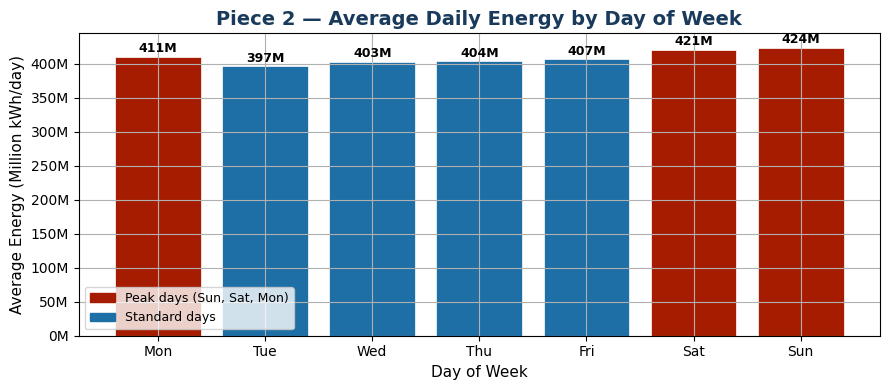

Saved: p2_dow_pattern.png


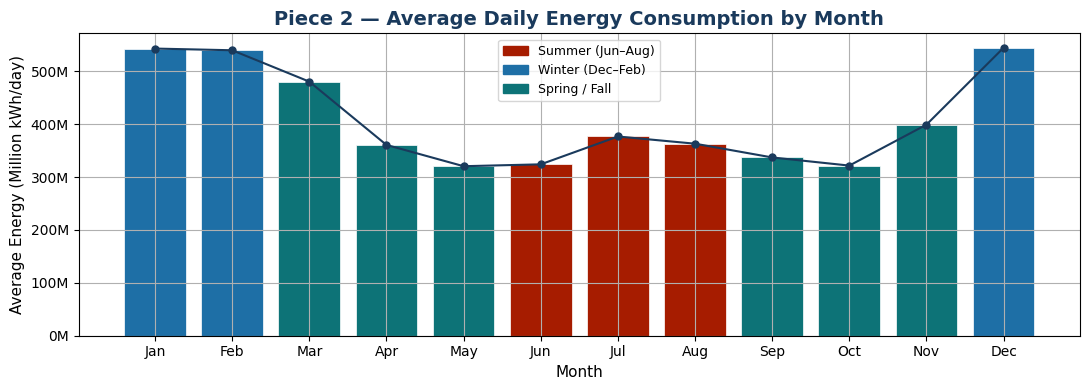

Saved: p2_monthly_pattern.png


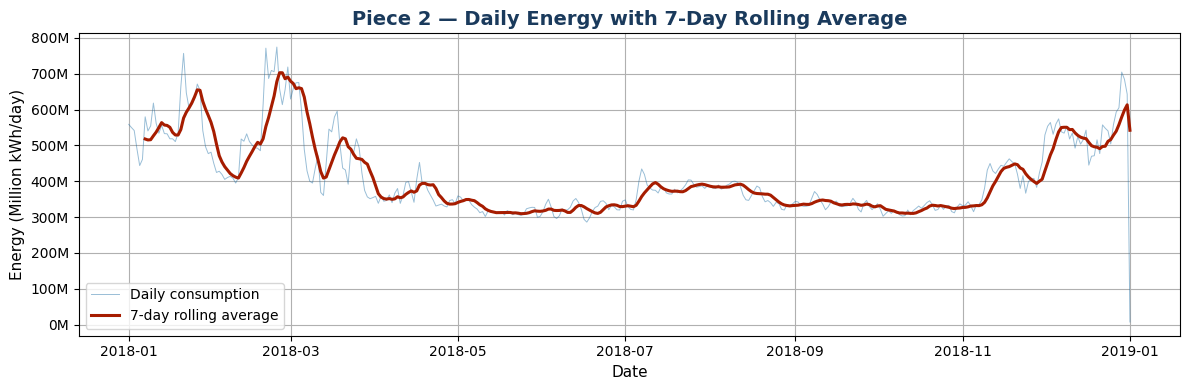

Saved: p2_rolling_avg.png


In [ ]:

# ── Save Piece 2 charts ─────────────────────────────────────────────────────
import matplotlib.patches as mpatches

# Chart 1: Day of week
dow_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_vals  = [daily_df[daily_df['day_name']==d]['energy_kwh'].mean()/1e6 for d in dow_order]
colors_dow = ['#A61C00' if d in peak_day_list else '#1E6FA6' for d in dow_order]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(dow_order, dow_vals, color=colors_dow, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, dow_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f'{val:.0f}M',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Piece 2 — Average Daily Energy by Day of Week', fontsize=14, fontweight='bold', color='#1A3A5C')
ax.set_xlabel('Day of Week', fontsize=11)
ax.set_ylabel('Average Energy (Million kWh/day)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
peak_patch  = mpatches.Patch(color='#A61C00', label='Peak days (Sun, Sat, Mon)')
other_patch = mpatches.Patch(color='#1E6FA6', label='Standard days')
ax.legend(handles=[peak_patch, other_patch], fontsize=9)
plt.tight_layout()
plt.savefig('p2_dow_pattern.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: p2_dow_pattern.png")

# Chart 2: Monthly pattern
month_vals   = [daily_df[daily_df['month']==m]['energy_kwh'].mean()/1e6 for m in range(1,13)]
month_names  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_colors = ['#A61C00' if m in [6,7,8] else '#1E6FA6' if m in [12,1,2] else '#0D7377' for m in range(1,13)]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(month_names, month_vals, color=month_colors, edgecolor='white', linewidth=0.5)
ax.plot(month_names, month_vals, color='#1A3A5C', marker='o', markersize=5, linewidth=1.5, zorder=5)
ax.set_title('Piece 2 — Average Daily Energy Consumption by Month', fontsize=14, fontweight='bold', color='#1A3A5C')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Average Energy (Million kWh/day)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
patches = [mpatches.Patch(color='#A61C00',label='Summer (Jun–Aug)'),
           mpatches.Patch(color='#1E6FA6',label='Winter (Dec–Feb)'),
           mpatches.Patch(color='#0D7377',label='Spring / Fall')]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.savefig('p2_monthly_pattern.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: p2_monthly_pattern.png")

# Chart 3: Rolling average
rolling7 = daily_df['energy_kwh'].rolling(7).mean()/1e6
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_df.index, daily_df['energy_kwh']/1e6, color='#1E6FA6', linewidth=0.7, alpha=0.45, label='Daily consumption')
ax.plot(daily_df.index, rolling7, color='#A61C00', linewidth=2.2, label='7-day rolling average')
ax.set_title('Piece 2 — Daily Energy with 7-Day Rolling Average', fontsize=14, fontweight='bold', color='#1A3A5C')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Energy (Million kWh/day)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('p2_rolling_avg.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: p2_rolling_avg.png")


## Piece 3 — Seasonal decomposition

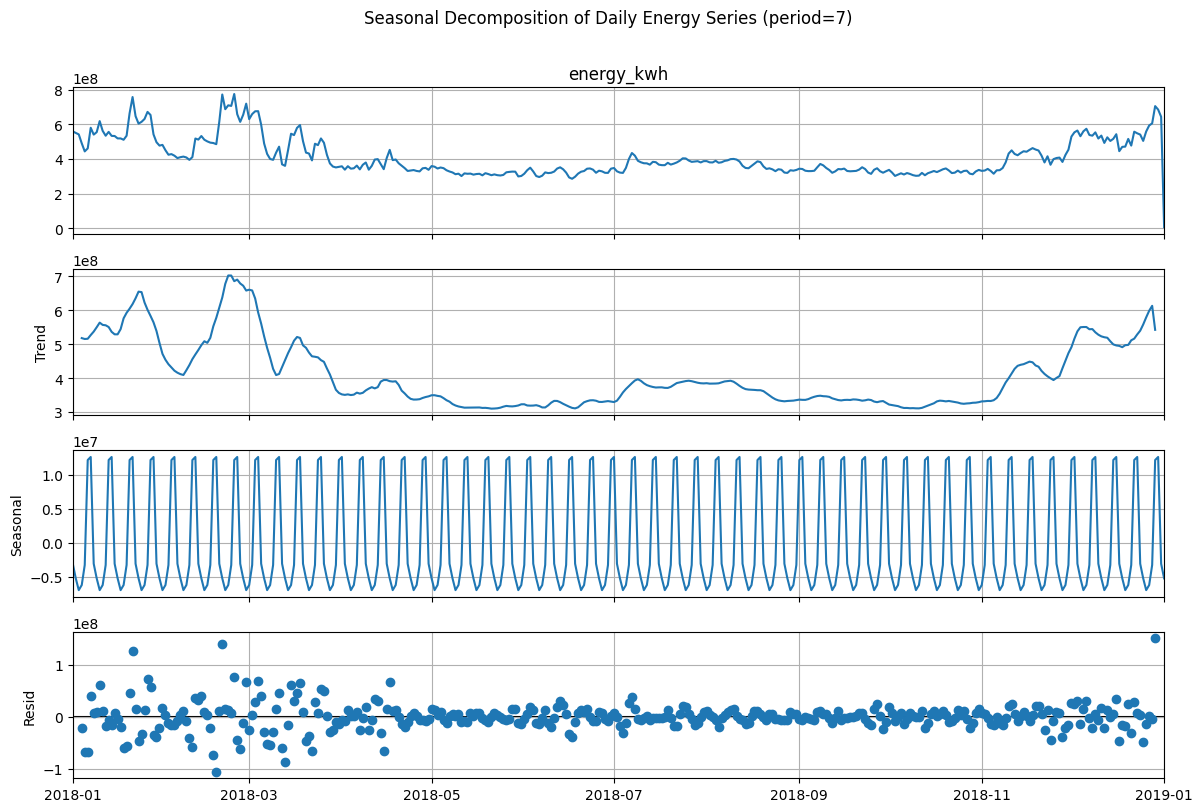

Saved: seasonal_decomposition_results.csv

Component summary:
         energy_kwh         trend     seasonal      residual
count  3.660000e+02  3.600000e+02       366.00  3.600000e+02
mean   4.092632e+08  4.077497e+08    -22778.33  3.461598e+04
std    1.074365e+08  9.767701e+07   7955779.80  2.682239e+07
min    7.549631e+06  3.096076e+08  -6979882.12 -1.052554e+08
25%    3.313237e+08  3.323152e+08  -6231824.59 -1.111136e+07
50%    3.694049e+08  3.722023e+08  -3275407.05 -9.531725e+04
75%    4.706345e+08  4.700694e+08  12187956.38  9.904431e+06
max    7.743233e+08  7.028173e+08  12636026.81  1.500194e+08


In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

series = daily_df["energy_kwh"]

# period=7 captures the weekly seasonal cycle in daily data
decomposition = seasonal_decompose(series, model="additive", period=7)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Seasonal Decomposition of Daily Energy Series (period=7)", y=1.01)
plt.tight_layout()
plt.show()

daily_df["trend"]    = decomposition.trend
daily_df["seasonal"] = decomposition.seasonal
daily_df["residual"] = decomposition.resid

daily_df[["energy_kwh","trend","seasonal","residual"]].to_csv("seasonal_decomposition_results.csv")
print("Saved: seasonal_decomposition_results.csv")
print()
print("Component summary:")
print(daily_df[["energy_kwh","trend","seasonal","residual"]].describe().round(2))


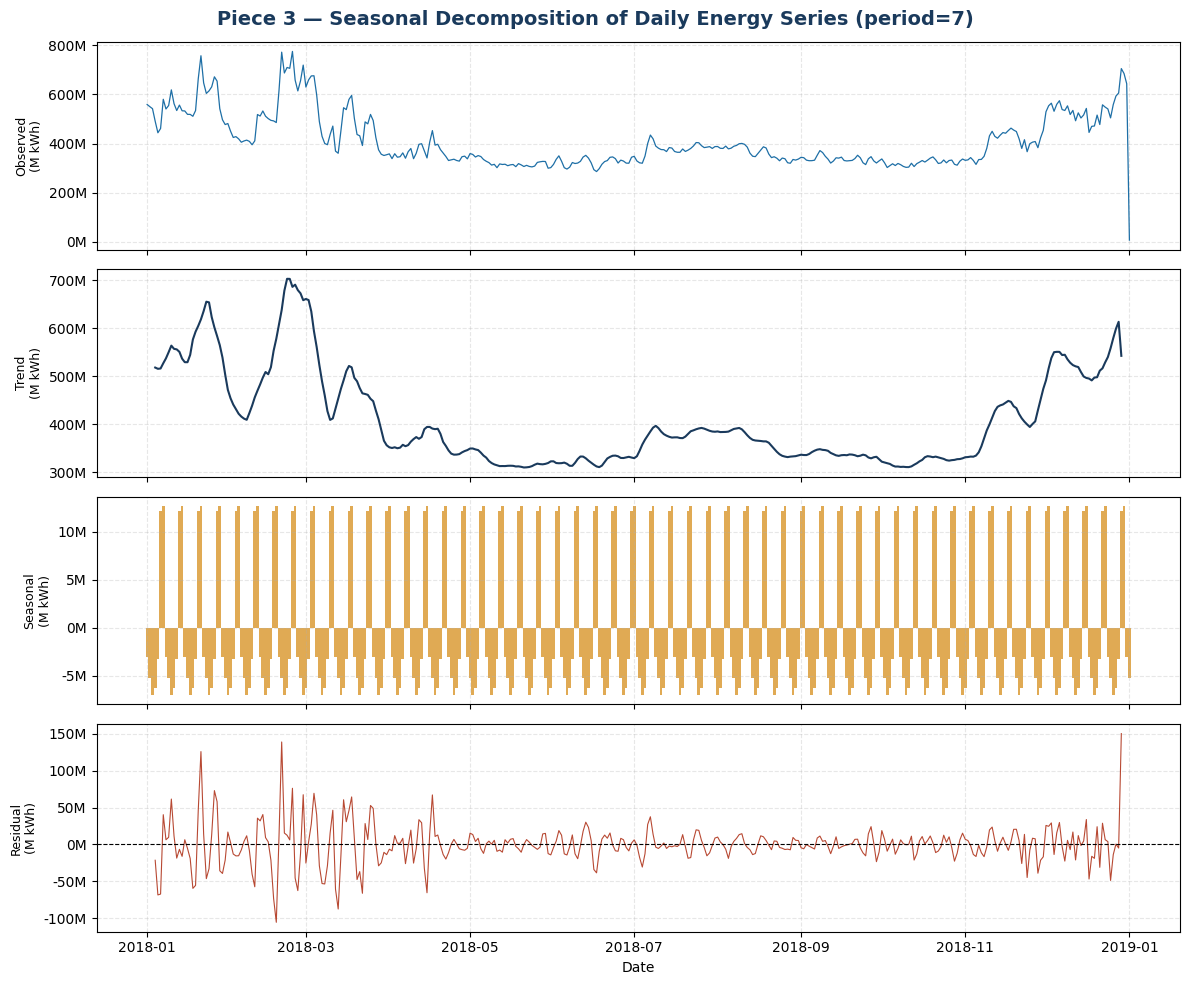

Saved: p3_decomposition.png


In [ ]:

# ── Save Piece 3 chart ──────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Piece 3 — Seasonal Decomposition of Daily Energy Series (period=7)',
             fontsize=14, fontweight='bold', color='#1A3A5C')
axes[0].plot(decomposition.observed/1e6, color='#1E6FA6', linewidth=0.9)
axes[0].set_ylabel('Observed\n(M kWh)', fontsize=9)
axes[1].plot(decomposition.trend/1e6, color='#1A3A5C', linewidth=1.5)
axes[1].set_ylabel('Trend\n(M kWh)', fontsize=9)
axes[2].bar(decomposition.seasonal.index, decomposition.seasonal/1e6,
            color='#D4860B', alpha=0.7, width=1)
axes[2].set_ylabel('Seasonal\n(M kWh)', fontsize=9)
axes[3].plot(decomposition.resid/1e6, color='#A61C00', linewidth=0.8, alpha=0.8)
axes[3].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[3].set_ylabel('Residual\n(M kWh)', fontsize=9)
axes[3].set_xlabel('Date', fontsize=10)
for ax in axes:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
    ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('p3_decomposition.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: p3_decomposition.png")


## Piece 4 — Stationarity test and differencing (ARIMA)


ADF Test — Original Daily Series
----------------------------------------
ADF Statistic : -2.5391
p-value       : 0.1062
Critical Values:
   1%: -3.4490
   5%: -2.8698
   10%: -2.5712
Conclusion    : NOT stationary

ADF Test — First Differenced Daily Series
----------------------------------------
ADF Statistic : -6.1128
p-value       : 0.0000
Critical Values:
   1%: -3.4490
   5%: -2.8698
   10%: -2.5712
Conclusion    : STATIONARY


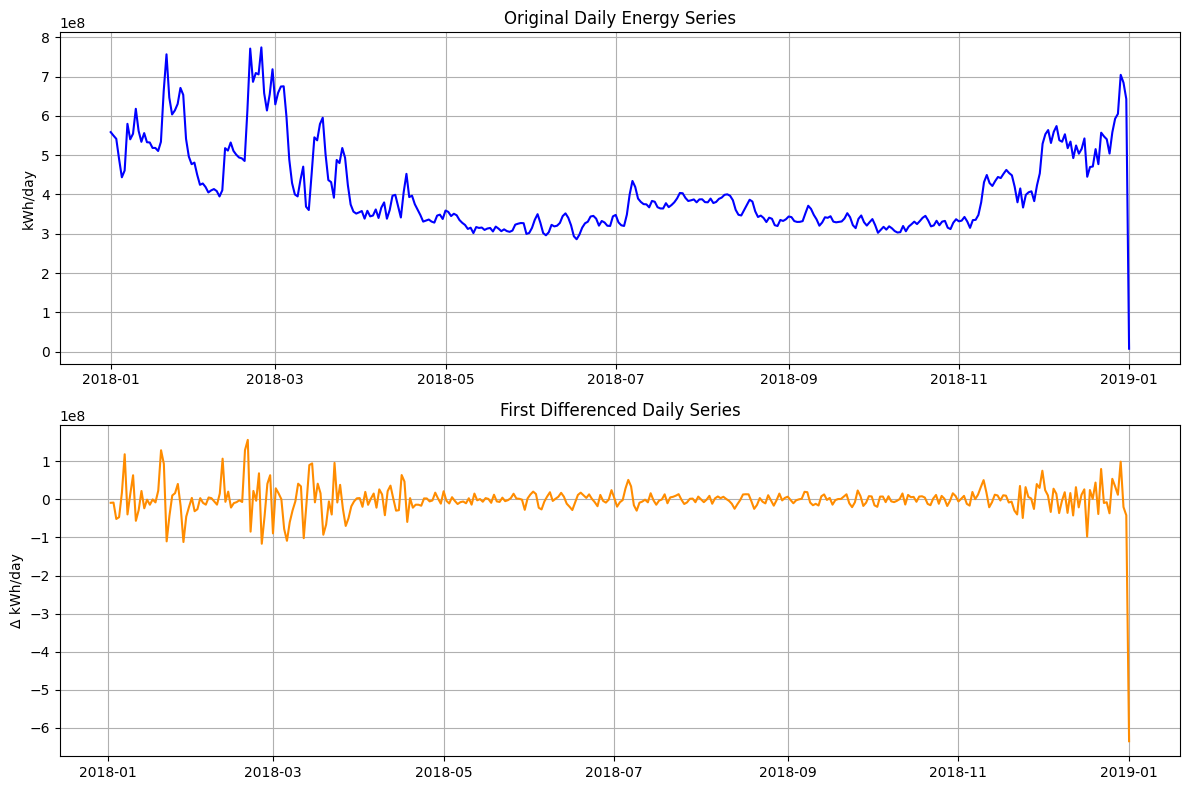


Selected differencing order d = 1


In [ ]:
from statsmodels.tsa.stattools import adfuller

def run_adf_test(input_series, series_name="Series"):
    result = adfuller(input_series.dropna())
    print(f"\nADF Test — {series_name}")
    print("-" * 40)
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print("Critical Values:")
    for key, val in result[4].items():
        print(f"   {key}: {val:.4f}")
    if result[1] < 0.05:
        print("Conclusion    : STATIONARY")
    else:
        print("Conclusion    : NOT stationary")

series = daily_df["energy_kwh"]
run_adf_test(series, "Original Daily Series")

# First differencing
diff_1 = series.diff().dropna()
run_adf_test(diff_1, "First Differenced Daily Series")

# Plot original and differenced series
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(series.index, series.values, color="blue")
axes[0].set_title("Original Daily Energy Series")
axes[0].set_ylabel("kWh/day")
axes[1].plot(diff_1.index, diff_1.values, color="darkorange")
axes[1].set_title("First Differenced Daily Series")
axes[1].set_ylabel("Δ kWh/day")
plt.tight_layout()
plt.show()

# Set d based on ADF result
d_value = 1   # update to 0 if original daily series is already stationary
print("\nSelected differencing order d =", d_value)


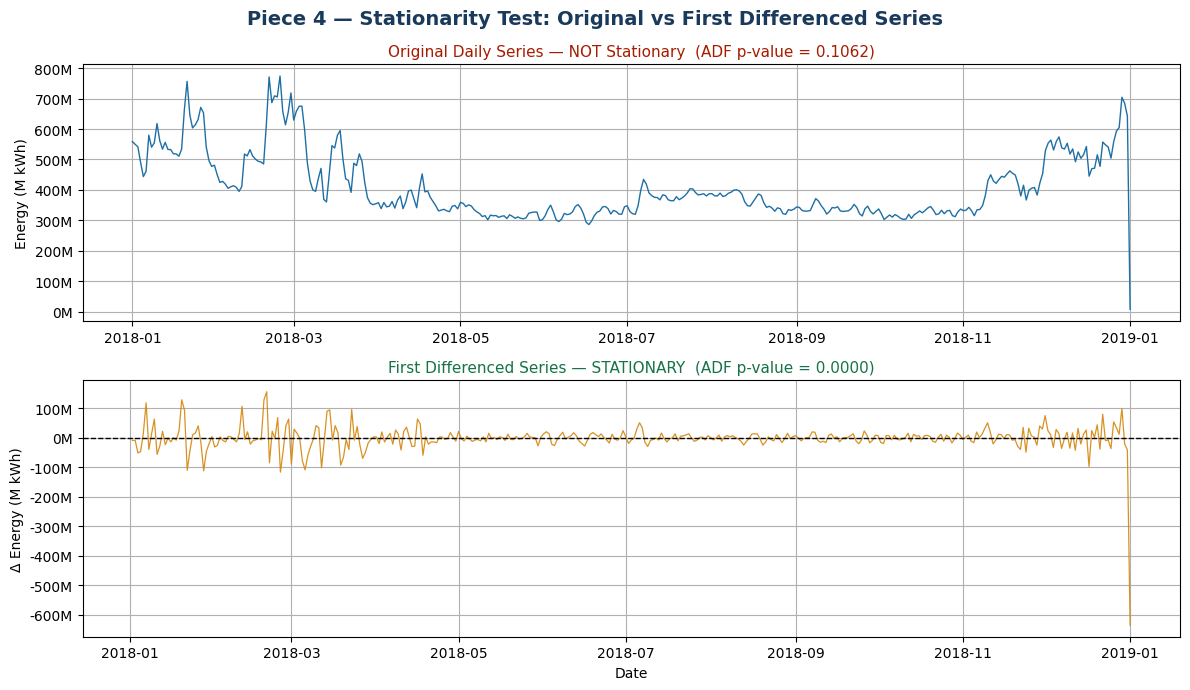

Saved: p4_stationarity.png


In [ ]:

# ── Save Piece 4 chart ──────────────────────────────────────────────────────
diff1 = series.diff().dropna()
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
fig.suptitle('Piece 4 — Stationarity Test: Original vs First Differenced Series',
             fontsize=14, fontweight='bold', color='#1A3A5C')
axes[0].plot(series.index, series/1e6, color='#1E6FA6', linewidth=1.0)
axes[0].set_title('Original Daily Series — NOT Stationary  (ADF p-value = 0.1062)',
                  fontsize=11, color='#A61C00')
axes[0].set_ylabel('Energy (M kWh)', fontsize=10)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
axes[1].plot(diff1.index, diff1/1e6, color='#D4860B', linewidth=0.9, alpha=0.9)
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('First Differenced Series — STATIONARY  (ADF p-value = 0.0000)',
                  fontsize=11, color='#157347')
axes[1].set_ylabel('Δ Energy (M kWh)', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
plt.tight_layout()
plt.savefig('p4_stationarity.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: p4_stationarity.png")


## Piece 5 — ARIMA parameter selection (ACF/PACF + AIC)

Training days : 292
Testing days  : 74


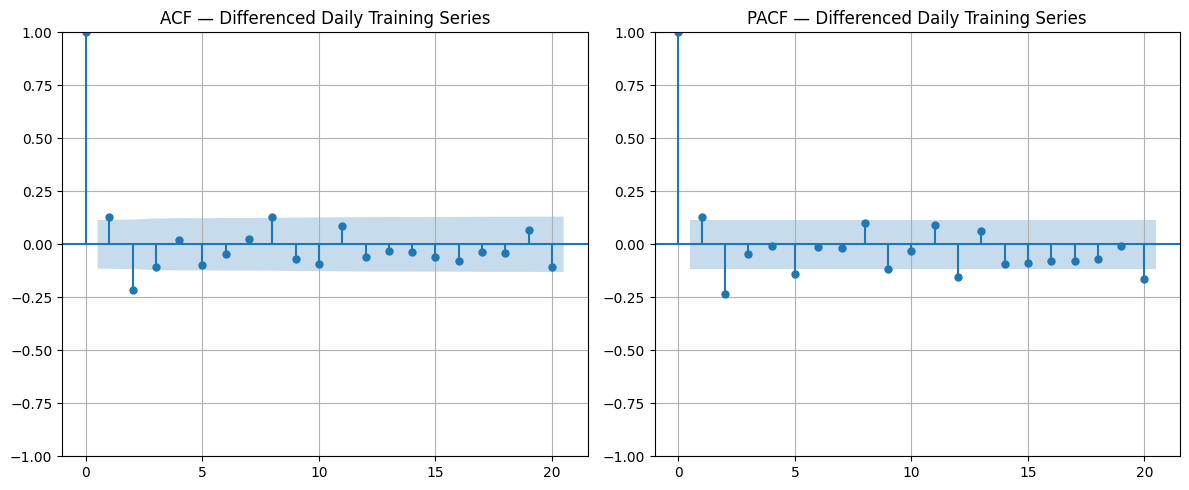

ARIMA(1, 1, 1)  AIC=10905.95  BIC=10916.97
ARIMA(2, 1, 1)  AIC=10897.31  BIC=10912.01
ARIMA(1, 1, 2)  AIC=10898.96  BIC=10913.65
ARIMA(2, 1, 2)  AIC=10899.20  BIC=10917.57
ARIMA(3, 1, 1)  AIC=10899.03  BIC=10917.40
ARIMA(1, 1, 3)  AIC=10900.43  BIC=10918.80

Ranked ARIMA candidates:
       Order       AIC       BIC
0  (2, 1, 1)  10897.31  10912.01
1  (1, 1, 2)  10898.96  10913.65
2  (3, 1, 1)  10899.03  10917.40
3  (2, 1, 2)  10899.20  10917.57
4  (1, 1, 3)  10900.43  10918.80
5  (1, 1, 1)  10905.95  10916.97

Best ARIMA order: (2, 1, 1)
                               SARIMAX Results                                
Dep. Variable:             energy_kwh   No. Observations:                  292
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -5444.656
Date:                Thu, 23 Apr 2026   AIC                          10897.312
Time:                        14:53:17   BIC                          10912.005
Sample:                    01-01-2018   HQIC                 

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

series = daily_df["energy_kwh"]
train_size = int(len(series) * 0.8)
train = series.iloc[:train_size]
test  = series.iloc[train_size:]

print(f"Training days : {len(train)}")
print(f"Testing days  : {len(test)}")

# Stationary training series for ACF/PACF
stationary_train = train.diff().dropna() if d_value == 1 else train.copy()

# Use lags=20 — sensible for daily data (covers ~3 weekly cycles)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_acf(stationary_train,  ax=axes[0], lags=20)
axes[0].set_title("ACF — Differenced Daily Training Series")
plot_pacf(stationary_train, ax=axes[1], lags=20, method="ywm")
axes[1].set_title("PACF — Differenced Daily Training Series")
plt.tight_layout()
plt.show()

# Candidate ARIMA orders
candidate_orders = [
    (1, d_value, 1), (2, d_value, 1), (1, d_value, 2),
    (2, d_value, 2), (3, d_value, 1), (1, d_value, 3)
]

aic_results = []
for order in candidate_orders:
    try:
        fit = ARIMA(train, order=order).fit()
        aic_results.append({"Order": order, "AIC": round(fit.aic,2), "BIC": round(fit.bic,2)})
        print(f"ARIMA{order}  AIC={fit.aic:.2f}  BIC={fit.bic:.2f}")
    except Exception as e:
        print(f"ARIMA{order} failed: {e}")

aic_df = pd.DataFrame(aic_results).sort_values("AIC").reset_index(drop=True)
print("\nRanked ARIMA candidates:")
print(aic_df)

best_order = aic_df.loc[0, "Order"]
print("\nBest ARIMA order:", best_order)

final_model_fit = ARIMA(train, order=best_order).fit()
print(final_model_fit.summary())


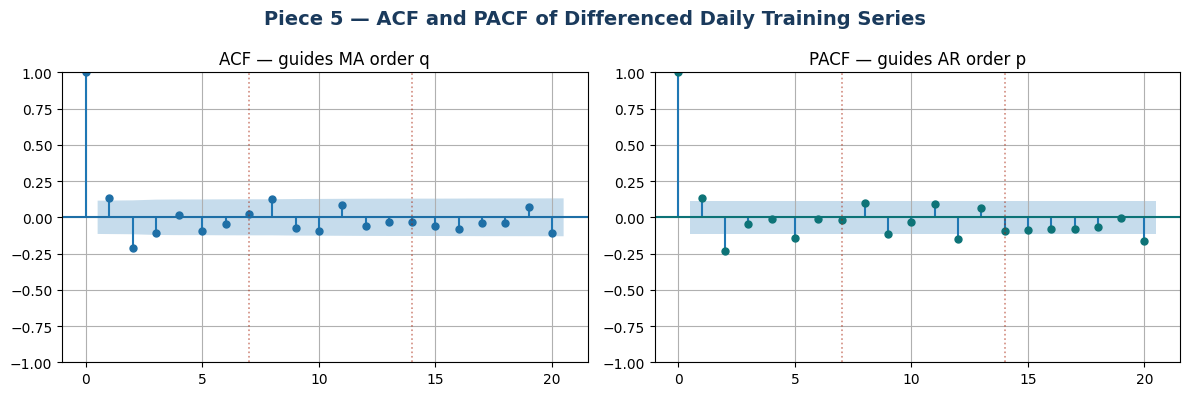

Saved: p5_acf_pacf.png


In [ ]:

# ── Save Piece 5 ACF/PACF chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Piece 5 — ACF and PACF of Differenced Daily Training Series',
             fontsize=14, fontweight='bold', color='#1A3A5C')
plot_acf( stationary_train, lags=20, ax=axes[0], color='#1E6FA6',
          title='ACF — guides MA order q')
plot_pacf(stationary_train, lags=20, ax=axes[1], color='#0D7377',
          title='PACF — guides AR order p', method='ywm')
axes[0].axvline(7,  color='#A61C00', linestyle=':', alpha=0.5, linewidth=1.2)
axes[0].axvline(14, color='#A61C00', linestyle=':', alpha=0.5, linewidth=1.2)
axes[1].axvline(7,  color='#A61C00', linestyle=':', alpha=0.5, linewidth=1.2)
axes[1].axvline(14, color='#A61C00', linestyle=':', alpha=0.5, linewidth=1.2)
plt.tight_layout()
plt.savefig('p5_acf_pacf.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: p5_acf_pacf.png")


## Piece 6 — ARIMA forecasting and evaluation (MAE, RMSE, MAPE, R²)

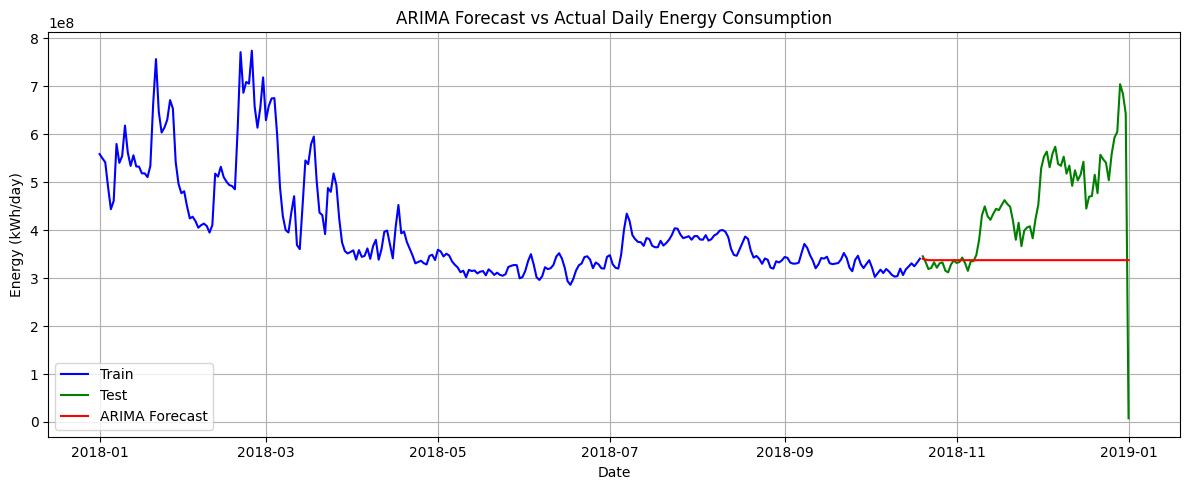


ARIMA — Overall Evaluation (Daily)
--------------------------------------
MAE  = 119297930.2578 kWh/day
RMSE = 152378284.1750 kWh/day
MAPE = 81.45%
R²   = -0.9312

ARIMA — Peak-Day Evaluation (Daily)
--------------------------------------
Peak days     : ['Sun', 'Sat', 'Mon']
Peak MAE  = 130304772.5468 kWh/day
Peak RMSE = 165527314.7526 kWh/day
Peak MAPE = 24.57%
Peak R²   = -1.2844


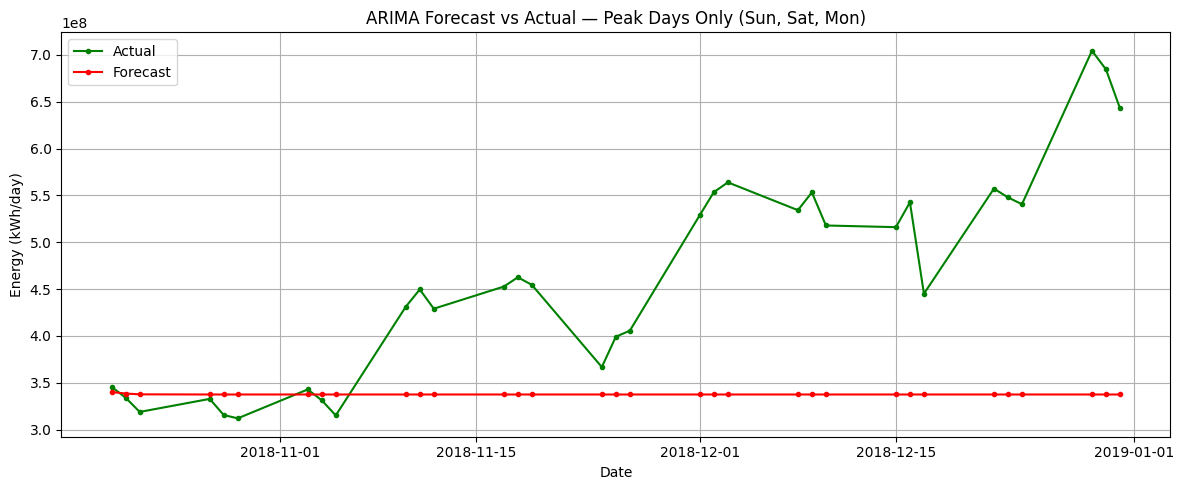

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Forecast
forecast = pd.Series(final_model_fit.forecast(steps=len(test)), index=test.index)

# Plot actual vs forecast
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Train", color="blue")
plt.plot(test.index,  test,  label="Test",  color="green")
plt.plot(forecast.index, forecast, label="ARIMA Forecast", color="red")
plt.title("ARIMA Forecast vs Actual Daily Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Energy (kWh/day)")
plt.legend()
plt.tight_layout()
plt.show()

# ── Overall evaluation ──────────────────────────────────────────────────────
mae  = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
r2   = r2_score(test, forecast)
safe_test = test.replace(0, np.nan)
mape = np.nanmean(np.abs((test - forecast) / safe_test)) * 100

print("\nARIMA — Overall Evaluation (Daily)")
print("-" * 38)
print(f"MAE  = {mae:.4f} kWh/day")
print(f"RMSE = {rmse:.4f} kWh/day")
print(f"MAPE = {mape:.2f}%")
print(f"R²   = {r2:.4f}")

# ── Peak-day-of-week evaluation ─────────────────────────────────────────────
# Peak days = top 3 day-of-week values identified in Piece 2
peak_mask     = test.index.dayofweek.isin(peak_dow_list)
peak_test     = test[peak_mask]
peak_forecast = forecast[peak_mask]

peak_mae  = mean_absolute_error(peak_test, peak_forecast)
peak_rmse = np.sqrt(mean_squared_error(peak_test, peak_forecast))
peak_r2   = r2_score(peak_test, peak_forecast)
safe_peak = peak_test.replace(0, np.nan)
peak_mape = np.nanmean(np.abs((peak_test - peak_forecast) / safe_peak)) * 100

print("\nARIMA — Peak-Day Evaluation (Daily)")
print("-" * 38)
print(f"Peak days     : {peak_day_list}")
print(f"Peak MAE  = {peak_mae:.4f} kWh/day")
print(f"Peak RMSE = {peak_rmse:.4f} kWh/day")
print(f"Peak MAPE = {peak_mape:.2f}%")
print(f"Peak R²   = {peak_r2:.4f}")

# Plot peak-day forecast
plt.figure(figsize=(12, 5))
plt.plot(peak_test.index,     peak_test.values,     label="Actual",   color="green", marker="o", markersize=3)
plt.plot(peak_forecast.index, peak_forecast.values, label="Forecast", color="red",   marker="o", markersize=3)
plt.title(f"ARIMA Forecast vs Actual — Peak Days Only ({', '.join(peak_day_list)})")
plt.xlabel("Date")
plt.ylabel("Energy (kWh/day)")
plt.legend()
plt.tight_layout()
plt.show()

# Store residuals for anomaly detection
results_df = pd.DataFrame({
    "actual":   test,
    "forecast": forecast,
    "residual": test - forecast
}, index=test.index)


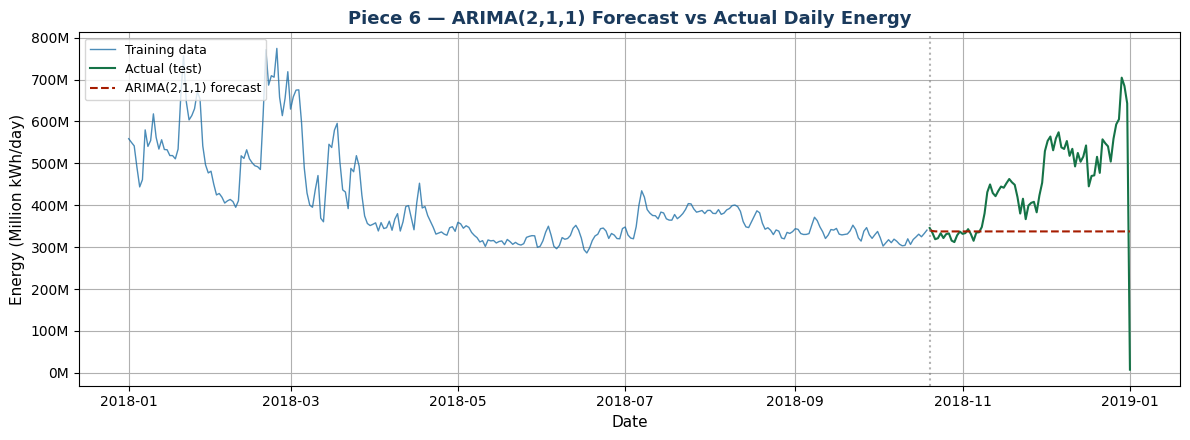

Saved: p6_arima_forecast.png


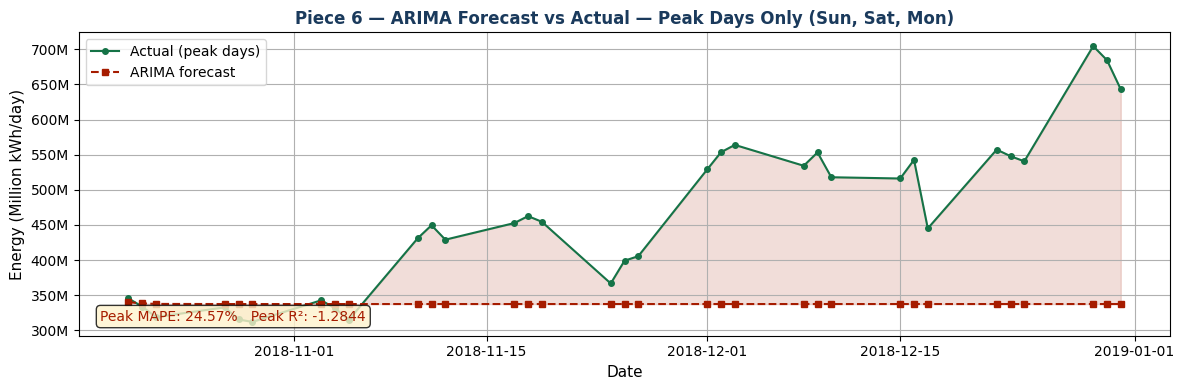

Saved: p6_arima_peak_forecast.png


In [ ]:

# ── Save Piece 6 charts ─────────────────────────────────────────────────────
peak_mask = test.index.dayofweek.isin([0, 5, 6])

# Chart 1: Full forecast
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(train.index, train/1e6,    color='#1E6FA6', linewidth=1.0, alpha=0.8, label='Training data')
ax.plot(test.index,  test/1e6,     color='#157347', linewidth=1.5, label='Actual (test)')
ax.plot(forecast.index, forecast/1e6, color='#A61C00', linewidth=1.5, linestyle='--', label='ARIMA(2,1,1) forecast')
ax.axvline(test.index[0], color='gray', linestyle=':', linewidth=1.5, alpha=0.6)
ax.set_title('Piece 6 — ARIMA(2,1,1) Forecast vs Actual Daily Energy', fontsize=13, fontweight='bold', color='#1A3A5C')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Energy (Million kWh/day)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('p6_arima_forecast.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: p6_arima_forecast.png")

# Chart 2: Peak days only
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(test.index[peak_mask], test[peak_mask]/1e6,
        color='#157347', marker='o', markersize=4, linewidth=1.5, label='Actual (peak days)')
ax.plot(test.index[peak_mask], forecast[peak_mask]/1e6,
        color='#A61C00', marker='s', markersize=4, linestyle='--', linewidth=1.5, label='ARIMA forecast')
ax.fill_between(test.index[peak_mask], test[peak_mask]/1e6, forecast[peak_mask]/1e6, alpha=0.15, color='#A61C00')
ax.set_title('Piece 6 — ARIMA Forecast vs Actual — Peak Days Only (Sun, Sat, Mon)', fontsize=12, fontweight='bold', color='#1A3A5C')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Energy (Million kWh/day)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax.legend(fontsize=10)
ax.text(0.02, 0.05, f'Peak MAPE: {peak_mape:.2f}%   Peak R²: {peak_r2:.4f}',
        transform=ax.transAxes, fontsize=10, color='#A61C00',
        bbox=dict(boxstyle='round', facecolor='#FEF3CD', alpha=0.8))
plt.tight_layout()
plt.savefig('p6_arima_peak_forecast.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: p6_arima_peak_forecast.png")


## Piece 7 — ARIMA residual analysis and anomaly detection

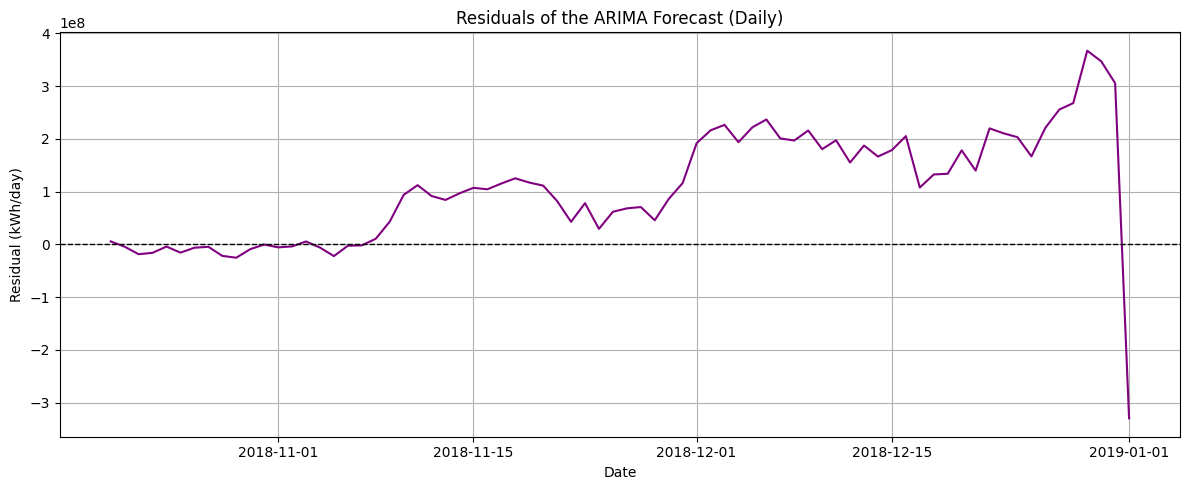

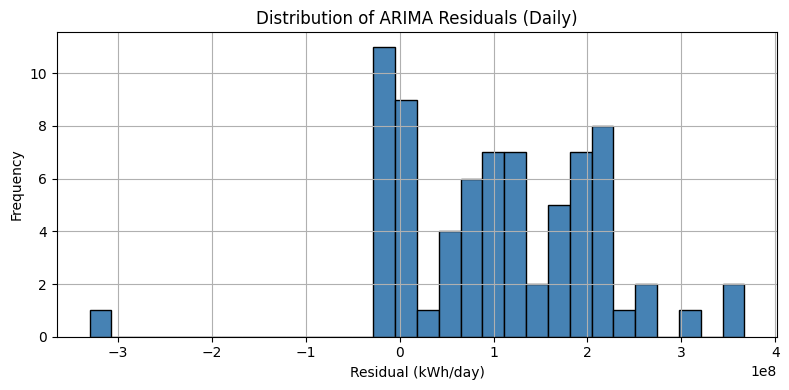

Total ARIMA anomalies detected: 1
                  actual      forecast      residual   z_score
timestamp                                                     
2019-01-01  7.549631e+06  3.374892e+08 -3.299395e+08 -3.944928


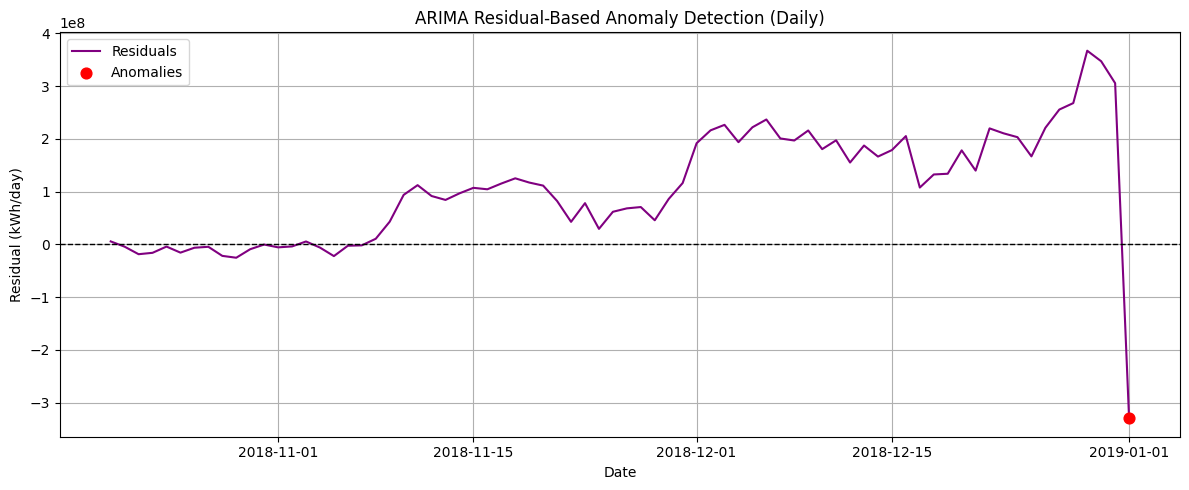

Peak-day ARIMA anomalies: 0


In [ ]:
# Residuals over time
plt.figure(figsize=(12, 5))
plt.plot(results_df.index, results_df["residual"], color="purple")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Residuals of the ARIMA Forecast (Daily)")
plt.xlabel("Date")
plt.ylabel("Residual (kWh/day)")
plt.tight_layout()
plt.show()

# Residual distribution
plt.figure(figsize=(8, 4))
plt.hist(results_df["residual"], bins=30, color="steelblue", edgecolor="black")
plt.title("Distribution of ARIMA Residuals (Daily)")
plt.xlabel("Residual (kWh/day)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Z-score anomaly detection
res_mean = results_df["residual"].mean()
res_std  = results_df["residual"].std()
results_df["z_score"]   = (results_df["residual"] - res_mean) / res_std
results_df["is_anomaly"] = results_df["z_score"].abs() > 3

anomalies_df = results_df[results_df["is_anomaly"]]
print(f"Total ARIMA anomalies detected: {len(anomalies_df)}")
if len(anomalies_df) > 0:
    print(anomalies_df[["actual","forecast","residual","z_score"]])

# Anomaly plot
plt.figure(figsize=(12, 5))
plt.plot(results_df.index, results_df["residual"], label="Residuals", color="purple")
plt.scatter(anomalies_df.index, anomalies_df["residual"], color="red", label="Anomalies", zorder=5, s=60)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("ARIMA Residual-Based Anomaly Detection (Daily)")
plt.xlabel("Date")
plt.ylabel("Residual (kWh/day)")
plt.legend()
plt.tight_layout()
plt.show()

# Peak-day anomalies
peak_anomalies_df = anomalies_df[anomalies_df.index.dayofweek.isin(peak_dow_list)]
print(f"Peak-day ARIMA anomalies: {len(peak_anomalies_df)}")


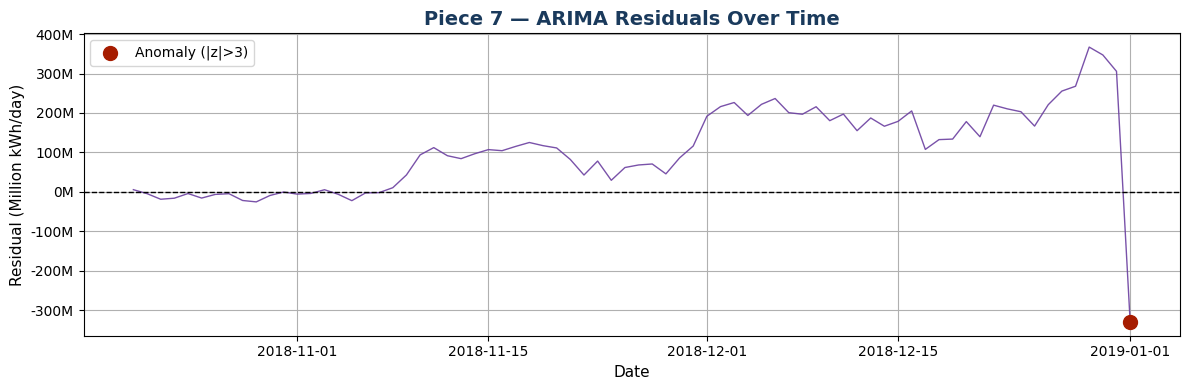

Saved: p7_residuals.png


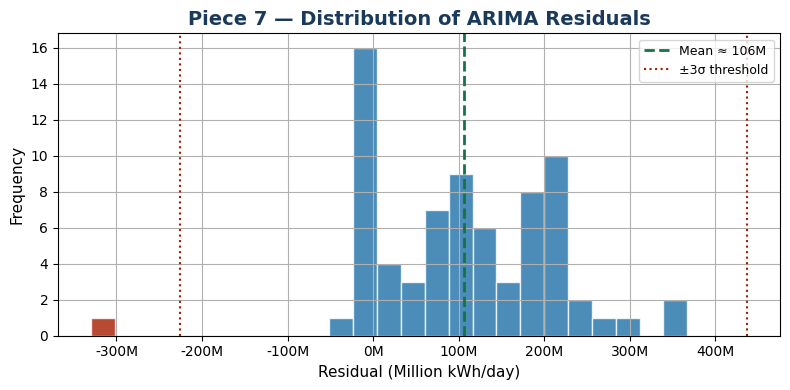

Saved: p7_hist.png


In [ ]:

# ── Save Piece 7 charts ─────────────────────────────────────────────────────
arima_resid = results_df['residual']
mean_r  = arima_resid.mean()
std_r   = arima_resid.std()

# Chart 1: Residuals over time (styled)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(arima_resid.index, arima_resid/1e6, color='#6B3FA0', linewidth=1.0, alpha=0.9)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
anom_mask = anomalies_df.index if 'anomalies_df' in dir() else results_df[abs((results_df['residual']-mean_r)/std_r) > 3].index
ax.scatter(anom_mask, arima_resid[anom_mask]/1e6, color='#A61C00', s=100, zorder=5, label='Anomaly (|z|>3)')
ax.set_title('Piece 7 — ARIMA Residuals Over Time', fontsize=14, fontweight='bold', color='#1A3A5C')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Residual (Million kWh/day)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('p7_residuals.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: p7_residuals.png")

# Chart 2: Residual histogram
fig, ax = plt.subplots(figsize=(8, 4))
n, bins, patches = ax.hist(arima_resid/1e6, bins=25, color='#1E6FA6', edgecolor='white', alpha=0.8)
for patch, left in zip(patches, bins[:-1]):
    if abs((left*1e6 - mean_r) / std_r) > 3:
        patch.set_facecolor('#A61C00')
ax.axvline(mean_r/1e6, color='#157347', linewidth=2, linestyle='--', label=f'Mean ≈ {mean_r/1e6:.0f}M')
ax.axvline((mean_r+3*std_r)/1e6, color='#A61C00', linewidth=1.5, linestyle=':', label='±3σ threshold')
ax.axvline((mean_r-3*std_r)/1e6, color='#A61C00', linewidth=1.5, linestyle=':')
ax.set_title('Piece 7 — Distribution of ARIMA Residuals', fontsize=14, fontweight='bold', color='#1A3A5C')
ax.set_xlabel('Residual (Million kWh/day)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('p7_hist.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: p7_hist.png")


## Piece 7B — ARIMA Ljung–Box residual autocorrelation test

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Use lag=7 because the data are daily and one weekly cycle = 7 days
arima_lb = acorr_ljungbox(results_df["residual"].dropna(), lags=[7], return_df=True)

arima_lb_stat = arima_lb["lb_stat"].iloc[0]
arima_lb_p = arima_lb["lb_pvalue"].iloc[0]

print("ARIMA Ljung–Box Test (lag=7, daily data)")
print(arima_lb.to_string())
print(f"\nARIMA p-value = {arima_lb_p:.4f} → " +
      ("no significant autocorrelation remains" if arima_lb_p > 0.05 else "significant autocorrelation remains"))


ARIMA Ljung–Box Test (lag=7, daily data)
      lb_stat     lb_pvalue
7  118.824975  1.345703e-22

ARIMA p-value = 0.0000 → significant autocorrelation remains


## SARIMA — Piece 1: Prepare daily series and confirm seasonal period

Training days  : 292
Testing days   : 74
Seasonal period: s = 7 (weekly cycle)


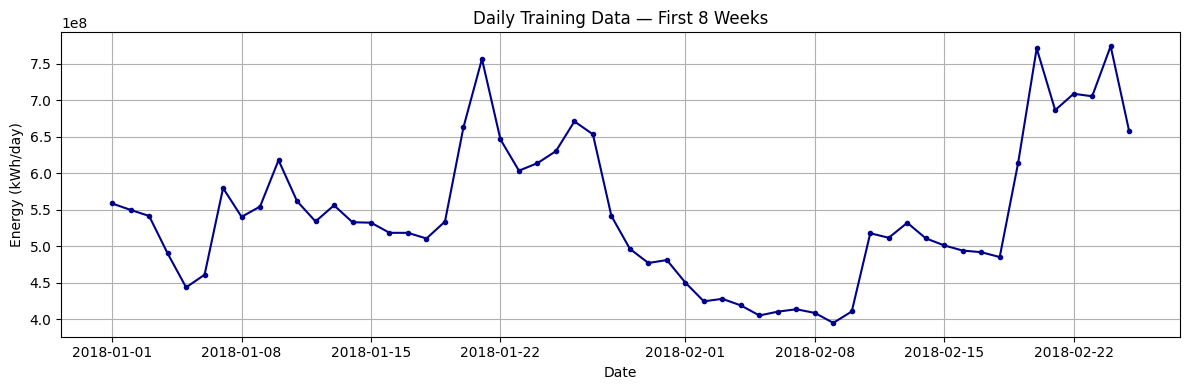

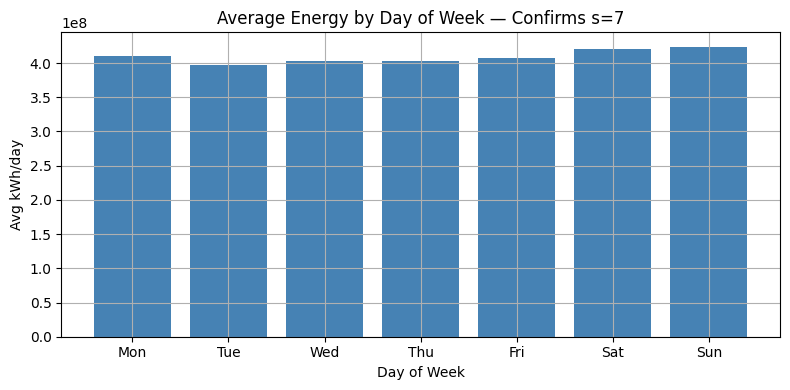

In [ ]:
# Use same series and same split as ARIMA for a fair comparison
series = daily_df["energy_kwh"]
train_size = int(len(series) * 0.8)
train = series.iloc[:train_size]
test  = series.iloc[train_size:]

# For daily data the natural seasonal cycle is 7 days (weekly)
seasonal_period = 7

print(f"Training days  : {len(train)}")
print(f"Testing days   : {len(test)}")
print(f"Seasonal period: s = {seasonal_period} (weekly cycle)")

# Plot first 8 weeks to confirm weekly pattern
sample_train = train.iloc[:7 * 8]
plt.figure(figsize=(12, 4))
plt.plot(sample_train.index, sample_train.values, color="darkblue", marker="o", markersize=3)
plt.title("Daily Training Data — First 8 Weeks")
plt.xlabel("Date")
plt.ylabel("Energy (kWh/day)")
plt.tight_layout()
plt.show()

# Also show the average weekly pattern
plt.figure(figsize=(8, 4))
plt.bar(daily_dow_pattern.index, daily_dow_pattern.values, color="steelblue")
plt.title("Average Energy by Day of Week — Confirms s=7")
plt.xlabel("Day of Week")
plt.ylabel("Avg kWh/day")
plt.tight_layout()
plt.show()


## SARIMA — Piece 2: Seasonal differencing and D selection


ADF Test — Seasonally Differenced Series (lag=7)
----------------------------------------
ADF Statistic : -5.9621
p-value       : 0.0000
Critical Values:
   1%: -3.4549
   5%: -2.8723
   10%: -2.5725
Conclusion    : STATIONARY

ADF Test — Regular + Seasonal Differenced Series
----------------------------------------
ADF Statistic : -7.1336
p-value       : 0.0000
Critical Values:
   1%: -3.4551
   5%: -2.8724
   10%: -2.5726
Conclusion    : STATIONARY


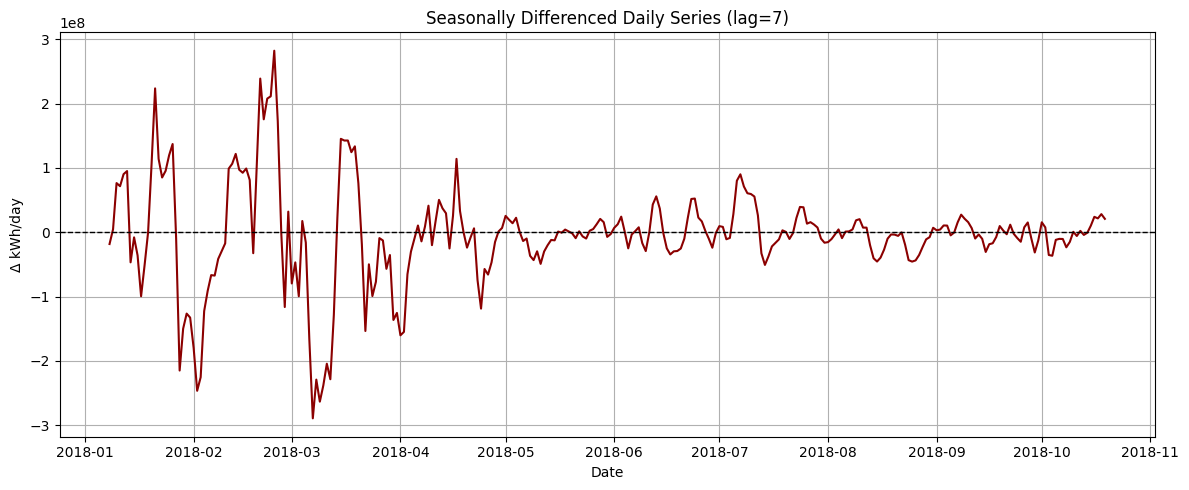


Selected seasonal differencing order D = 1


In [ ]:
# Seasonal differencing with lag=7 (remove weekly cycle)
seasonal_diff = train.diff(seasonal_period).dropna()
run_adf_test(seasonal_diff, "Seasonally Differenced Series (lag=7)")

# Combined regular + seasonal differencing
combined_diff = train.diff().diff(seasonal_period).dropna()
run_adf_test(combined_diff, "Regular + Seasonal Differenced Series")

plt.figure(figsize=(12, 5))
plt.plot(seasonal_diff.index, seasonal_diff.values, color="darkred")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Seasonally Differenced Daily Series (lag=7)")
plt.xlabel("Date")
plt.ylabel("Δ kWh/day")
plt.tight_layout()
plt.show()

D_value = 1   # update based on ADF result above
print("\nSelected seasonal differencing order D =", D_value)


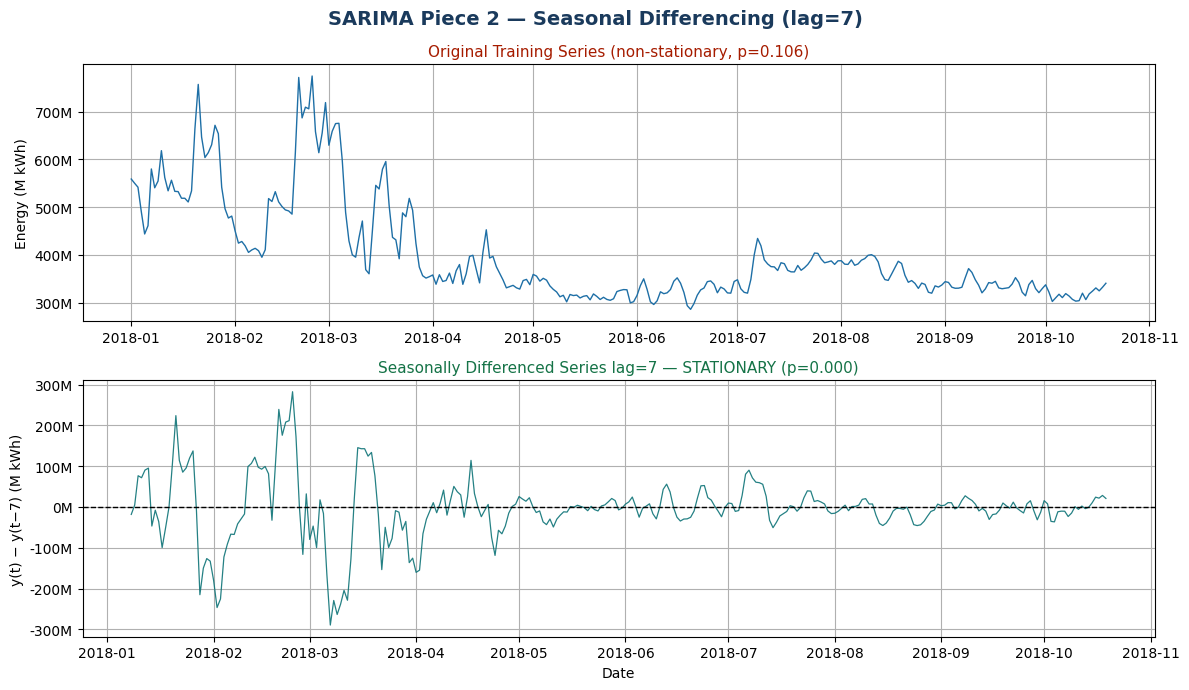

Saved: s2_seasonal_diff.png


In [ ]:

# ── Save SARIMA Piece 2 chart ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
fig.suptitle('SARIMA Piece 2 — Seasonal Differencing (lag=7)',
             fontsize=14, fontweight='bold', color='#1A3A5C')
axes[0].plot(train.index, train/1e6, color='#1E6FA6', linewidth=1.0)
axes[0].set_title('Original Training Series (non-stationary, p=0.106)', fontsize=11, color='#A61C00')
axes[0].set_ylabel('Energy (M kWh)', fontsize=10)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
axes[1].plot(seasonal_diff.index, seasonal_diff/1e6, color='#0D7377', linewidth=0.9, alpha=0.9)
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Seasonally Differenced Series lag=7 — STATIONARY (p=0.000)', fontsize=11, color='#157347')
axes[1].set_ylabel('y(t) − y(t−7) (M kWh)', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
plt.tight_layout()
plt.savefig('s2_seasonal_diff.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: s2_seasonal_diff.png")


## SARIMA — Piece 3: ACF/PACF and candidate seasonal orders

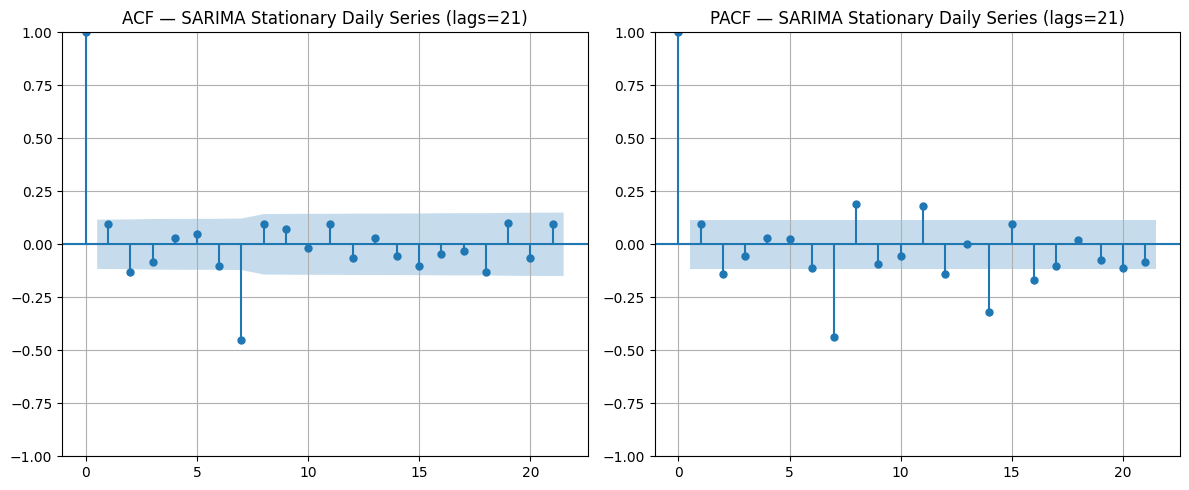

Candidate SARIMA models (s=7):
  SARIMA(0, 1, 1) x (0, 1, 1, 7)
  SARIMA(1, 1, 0) x (0, 1, 1, 7)
  SARIMA(1, 1, 1) x (0, 1, 1, 7)
  SARIMA(1, 1, 1) x (1, 1, 0, 7)
  SARIMA(1, 1, 1) x (1, 1, 1, 7)
  SARIMA(2, 1, 1) x (1, 1, 0, 7)
  SARIMA(1, 1, 2) x (0, 1, 1, 7)


In [ ]:
# Build stationary series for SARIMA inspection
if d_value == 1 and D_value == 1:
    sarima_stationary = train.diff().diff(seasonal_period).dropna()
elif d_value == 1 and D_value == 0:
    sarima_stationary = train.diff().dropna()
elif d_value == 0 and D_value == 1:
    sarima_stationary = train.diff(seasonal_period).dropna()
else:
    sarima_stationary = train.copy()

# Use lags=21 — covers 3 full weekly cycles (3 × 7 = 21)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_acf( sarima_stationary, ax=axes[0], lags=21)
axes[0].set_title("ACF — SARIMA Stationary Daily Series (lags=21)")
plot_pacf(sarima_stationary, ax=axes[1], lags=21, method="ywm")
axes[1].set_title("PACF — SARIMA Stationary Daily Series (lags=21)")
plt.tight_layout()
plt.show()

# Candidate SARIMA orders — seasonal period is now 7
candidate_sarima_orders = [
    ((0, d_value, 1), (0, D_value, 1, seasonal_period)),
    ((1, d_value, 0), (0, D_value, 1, seasonal_period)),
    ((1, d_value, 1), (0, D_value, 1, seasonal_period)),
    ((1, d_value, 1), (1, D_value, 0, seasonal_period)),
    ((1, d_value, 1), (1, D_value, 1, seasonal_period)),
    ((2, d_value, 1), (1, D_value, 0, seasonal_period)),
    ((1, d_value, 2), (0, D_value, 1, seasonal_period)),
]

print("Candidate SARIMA models (s=7):")
for o, s in candidate_sarima_orders:
    print(f"  SARIMA{o} x {s}")


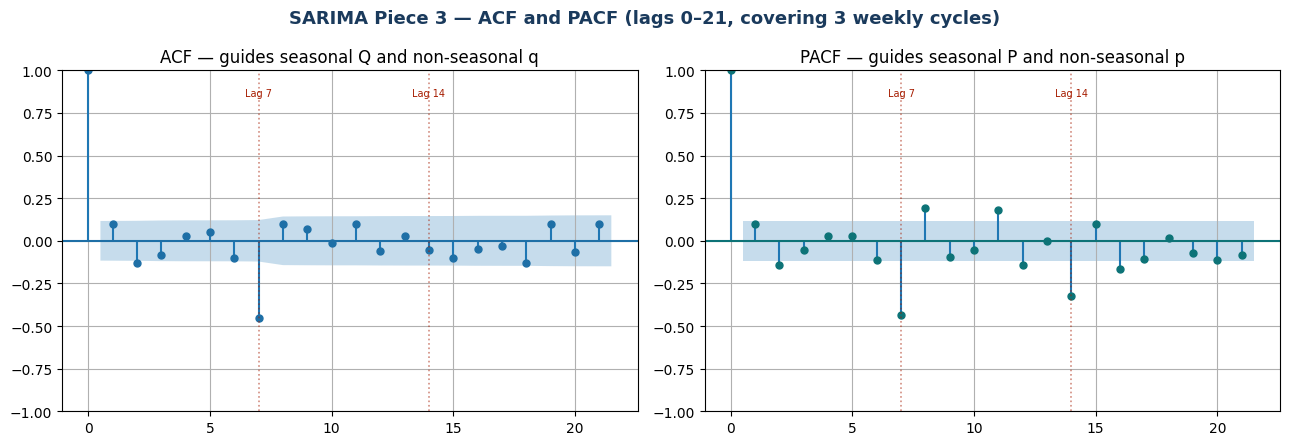

Saved: s3_sarima_acf_pacf.png


In [ ]:

# ── Save SARIMA Piece 3 ACF/PACF chart ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('SARIMA Piece 3 — ACF and PACF (lags 0–21, covering 3 weekly cycles)',
             fontsize=13, fontweight='bold', color='#1A3A5C')
plot_acf( sarima_stationary, lags=21, ax=axes[0], color='#1E6FA6',
          title='ACF — guides seasonal Q and non-seasonal q')
plot_pacf(sarima_stationary, lags=21, ax=axes[1], color='#0D7377',
          title='PACF — guides seasonal P and non-seasonal p', method='ywm')
for ax in axes:
    for lag in [7, 14]:
        ax.axvline(lag, color='#A61C00', linestyle=':', alpha=0.5, linewidth=1.2)
        ax.text(lag, 0.85, f'Lag {lag}', fontsize=7, color='#A61C00', ha='center')
plt.tight_layout()
plt.savefig('s3_sarima_acf_pacf.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: s3_sarima_acf_pacf.png")


## SARIMA — Piece 4: Fit candidates and select best by AIC

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_results = []
for order, seasonal_order in candidate_sarima_orders:
    try:
        fit = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        sarima_results.append({
            "Order": order,
            "Seasonal_Order": seasonal_order,
            "AIC": round(fit.aic, 2),
            "BIC": round(fit.bic, 2)
        })
        print(f"Fitted SARIMA{order} x {seasonal_order}  AIC={fit.aic:.2f}")
    except Exception as e:
        print(f"Failed SARIMA{order} x {seasonal_order}: {e}")

sarima_aic_df = pd.DataFrame(sarima_results).sort_values("AIC").reset_index(drop=True)
print("\nRanked SARIMA candidates:")
print(sarima_aic_df)

best_sarima_order          = sarima_aic_df.loc[0, "Order"]
best_sarima_seasonal_order = sarima_aic_df.loc[0, "Seasonal_Order"]
print("\nBest SARIMA order         :", best_sarima_order)
print("Best SARIMA seasonal order:", best_sarima_seasonal_order)

final_sarima_fit = SARIMAX(
    train,
    order=best_sarima_order,
    seasonal_order=best_sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(final_sarima_fit.summary())


Fitted SARIMA(0, 1, 1) x (0, 1, 1, 7)  AIC=10406.39
Fitted SARIMA(1, 1, 0) x (0, 1, 1, 7)  AIC=10445.29
Fitted SARIMA(1, 1, 1) x (0, 1, 1, 7)  AIC=10407.94
Fitted SARIMA(1, 1, 1) x (1, 1, 0, 7)  AIC=10459.84
Fitted SARIMA(1, 1, 1) x (1, 1, 1, 7)  AIC=10407.84
Fitted SARIMA(2, 1, 1) x (1, 1, 0, 7)  AIC=10415.25
Fitted SARIMA(1, 1, 2) x (0, 1, 1, 7)  AIC=10363.37

Ranked SARIMA candidates:
       Order Seasonal_Order       AIC       BIC
0  (1, 1, 2)   (0, 1, 1, 7)  10363.37  10381.44
1  (0, 1, 1)   (0, 1, 1, 7)  10406.39  10417.24
2  (1, 1, 1)   (1, 1, 1, 7)  10407.84  10425.93
3  (1, 1, 1)   (0, 1, 1, 7)  10407.94  10422.41
4  (2, 1, 1)   (1, 1, 0, 7)  10415.25  10433.33
5  (1, 1, 0)   (0, 1, 1, 7)  10445.29  10456.16
6  (1, 1, 1)   (1, 1, 0, 7)  10459.84  10474.32

Best SARIMA order         : (1, 1, 2)
Best SARIMA seasonal order: (0, 1, 1, 7)
                                      SARIMAX Results                                      
Dep. Variable:                          energy_kwh   

## SARIMA — Piece 5: Forecasting and evaluation (MAE, RMSE, MAPE, R²)

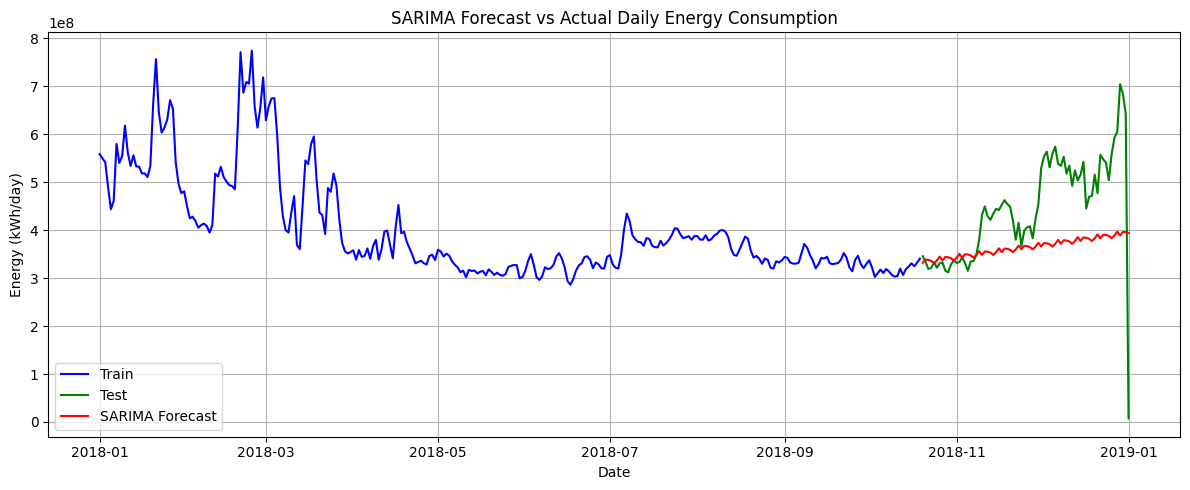


SARIMA — Overall Evaluation (Daily)
--------------------------------------
MAE  = 96104620.6550 kWh/day
RMSE = 126202617.9346 kWh/day
MAPE = 86.87%
R²   = -0.3247

SARIMA — Peak-Day Evaluation (Daily)
--------------------------------------
Peak days     : ['Sun', 'Sat', 'Mon']
Peak MAE  = 105411235.7647 kWh/day
Peak RMSE = 134610142.8883 kWh/day
Peak MAPE = 19.95%
Peak R²   = -0.5107


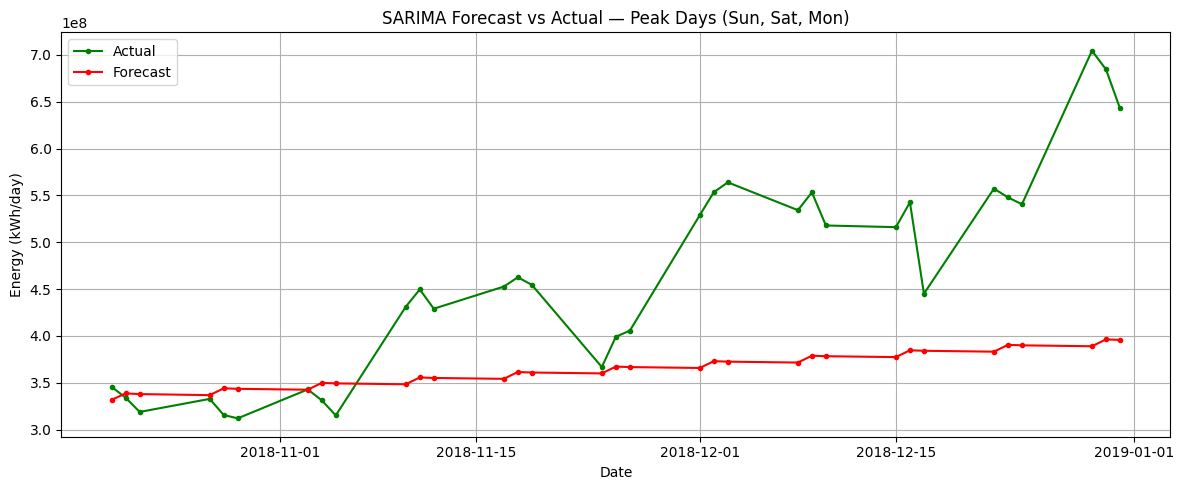

In [ ]:
sarima_forecast = pd.Series(final_sarima_fit.forecast(steps=len(test)), index=test.index)

# Plot actual vs SARIMA forecast
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Train", color="blue")
plt.plot(test.index,  test,  label="Test",  color="green")
plt.plot(sarima_forecast.index, sarima_forecast, label="SARIMA Forecast", color="red")
plt.title("SARIMA Forecast vs Actual Daily Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Energy (kWh/day)")
plt.legend()
plt.tight_layout()
plt.show()

# ── Overall evaluation ──────────────────────────────────────────────────────
sarima_mae  = mean_absolute_error(test, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
sarima_r2   = r2_score(test, sarima_forecast)
safe_test   = test.replace(0, np.nan)
sarima_mape = np.nanmean(np.abs((test - sarima_forecast) / safe_test)) * 100

print("\nSARIMA — Overall Evaluation (Daily)")
print("-" * 38)
print(f"MAE  = {sarima_mae:.4f} kWh/day")
print(f"RMSE = {sarima_rmse:.4f} kWh/day")
print(f"MAPE = {sarima_mape:.2f}%")
print(f"R²   = {sarima_r2:.4f}")

# ── Peak-day-of-week evaluation ─────────────────────────────────────────────
peak_mask            = test.index.dayofweek.isin(peak_dow_list)
peak_test            = test[peak_mask]
peak_sarima_forecast = sarima_forecast[peak_mask]

sarima_peak_mae  = mean_absolute_error(peak_test, peak_sarima_forecast)
sarima_peak_rmse = np.sqrt(mean_squared_error(peak_test, peak_sarima_forecast))
sarima_peak_r2   = r2_score(peak_test, peak_sarima_forecast)
safe_peak        = peak_test.replace(0, np.nan)
sarima_peak_mape = np.nanmean(np.abs((peak_test - peak_sarima_forecast) / safe_peak)) * 100

print("\nSARIMA — Peak-Day Evaluation (Daily)")
print("-" * 38)
print(f"Peak days     : {peak_day_list}")
print(f"Peak MAE  = {sarima_peak_mae:.4f} kWh/day")
print(f"Peak RMSE = {sarima_peak_rmse:.4f} kWh/day")
print(f"Peak MAPE = {sarima_peak_mape:.2f}%")
print(f"Peak R²   = {sarima_peak_r2:.4f}")

# Plot peak-day forecast
plt.figure(figsize=(12, 5))
plt.plot(peak_test.index,            peak_test.values,            label="Actual",   color="green", marker="o", markersize=3)
plt.plot(peak_sarima_forecast.index, peak_sarima_forecast.values, label="Forecast", color="red",   marker="o", markersize=3)
plt.title(f"SARIMA Forecast vs Actual — Peak Days ({', '.join(peak_day_list)})")
plt.xlabel("Date")
plt.ylabel("Energy (kWh/day)")
plt.legend()
plt.tight_layout()
plt.show()

# Store residuals
sarima_results_df = pd.DataFrame({
    "actual":   test,
    "forecast": sarima_forecast,
    "residual": test - sarima_forecast
}, index=test.index)


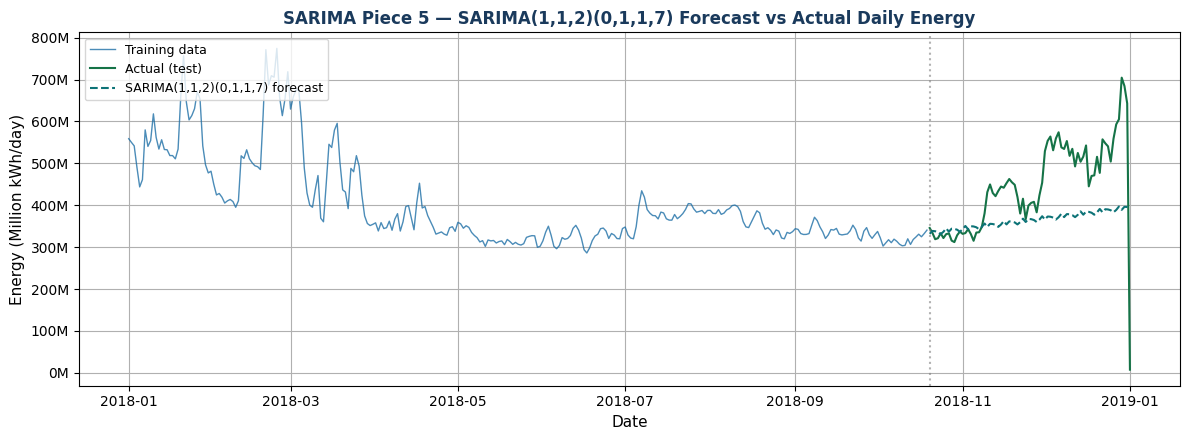

Saved: s5_sarima_forecast.png


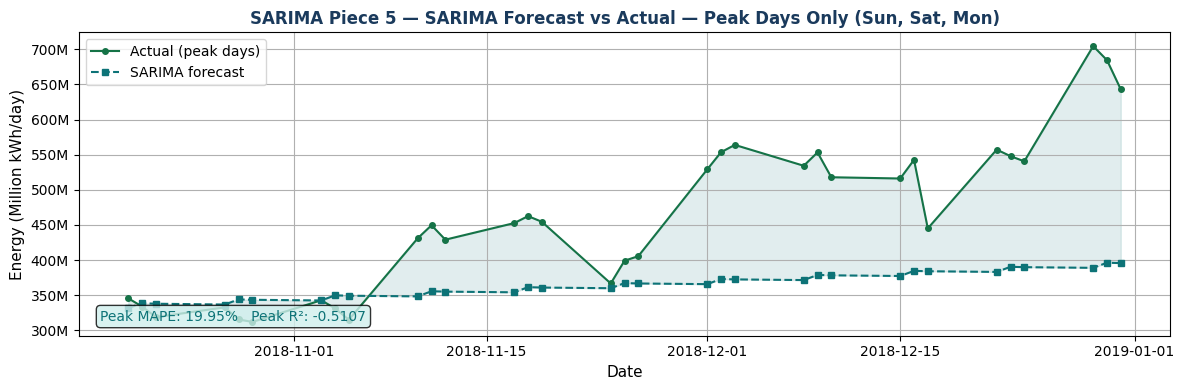

Saved: s5_sarima_peak_forecast.png


In [ ]:

# ── Save SARIMA Piece 5 charts ───────────────────────────────────────────────
peak_mask = test.index.dayofweek.isin([0, 5, 6])

# Chart 1: Full SARIMA forecast
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(train.index, train/1e6, color='#1E6FA6', linewidth=1.0, alpha=0.8, label='Training data')
ax.plot(test.index,  test/1e6,  color='#157347', linewidth=1.5, label='Actual (test)')
ax.plot(sarima_forecast.index, sarima_forecast/1e6,
        color='#0D7377', linewidth=1.5, linestyle='--', label='SARIMA(1,1,2)(0,1,1,7) forecast')
ax.axvline(test.index[0], color='gray', linestyle=':', linewidth=1.5, alpha=0.6)
ax.set_title('SARIMA Piece 5 — SARIMA(1,1,2)(0,1,1,7) Forecast vs Actual Daily Energy',
             fontsize=12, fontweight='bold', color='#1A3A5C')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Energy (Million kWh/day)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('s5_sarima_forecast.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: s5_sarima_forecast.png")

# Chart 2: Peak days only
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(test.index[peak_mask], test[peak_mask]/1e6,
        color='#157347', marker='o', markersize=4, linewidth=1.5, label='Actual (peak days)')
ax.plot(test.index[peak_mask], sarima_forecast[peak_mask]/1e6,
        color='#0D7377', marker='s', markersize=4, linestyle='--', linewidth=1.5, label='SARIMA forecast')
ax.fill_between(test.index[peak_mask], test[peak_mask]/1e6, sarima_forecast[peak_mask]/1e6,
                alpha=0.12, color='#0D7377')
ax.set_title('SARIMA Piece 5 — SARIMA Forecast vs Actual — Peak Days Only (Sun, Sat, Mon)',
             fontsize=12, fontweight='bold', color='#1A3A5C')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Energy (Million kWh/day)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax.legend(fontsize=10)
ax.text(0.02, 0.05, f'Peak MAPE: {sarima_peak_mape:.2f}%   Peak R²: {sarima_peak_r2:.4f}',
        transform=ax.transAxes, fontsize=10, color='#0D7377',
        bbox=dict(boxstyle='round', facecolor='#D0EFED', alpha=0.8))
plt.tight_layout()
plt.savefig('s5_sarima_peak_forecast.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: s5_sarima_peak_forecast.png")


## SARIMA — Piece 6: Residual analysis and anomaly detection

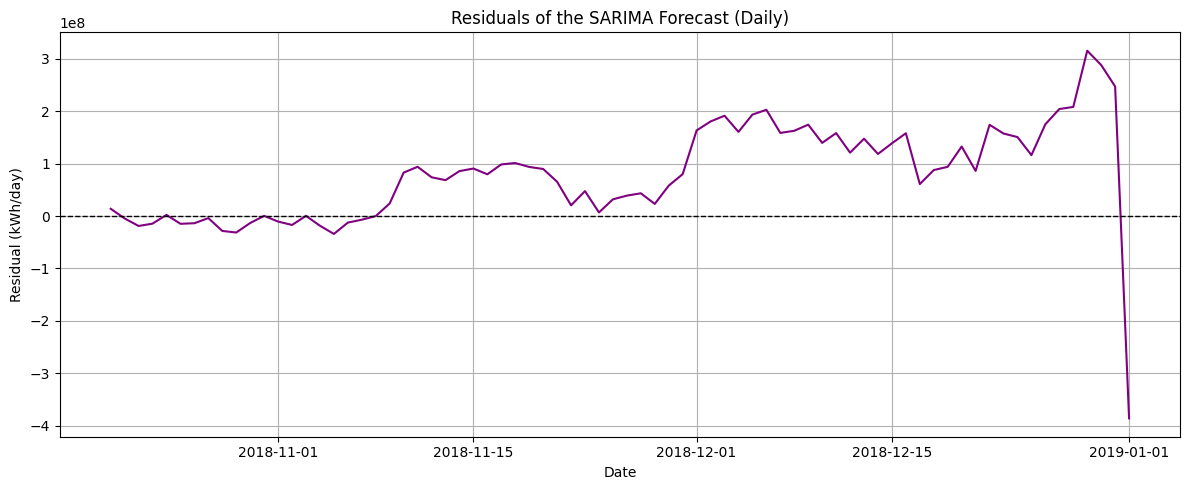

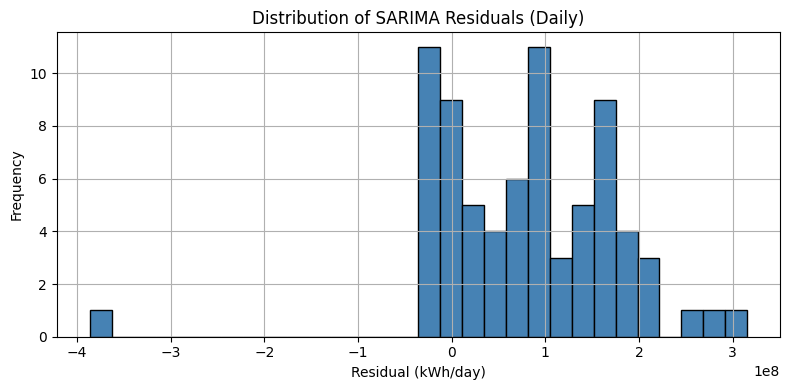

Total SARIMA anomalies detected: 1
                  actual      forecast      residual   z_score
timestamp                                                     
2019-01-01  7.549631e+06  3.937803e+08 -3.862307e+08 -4.697533


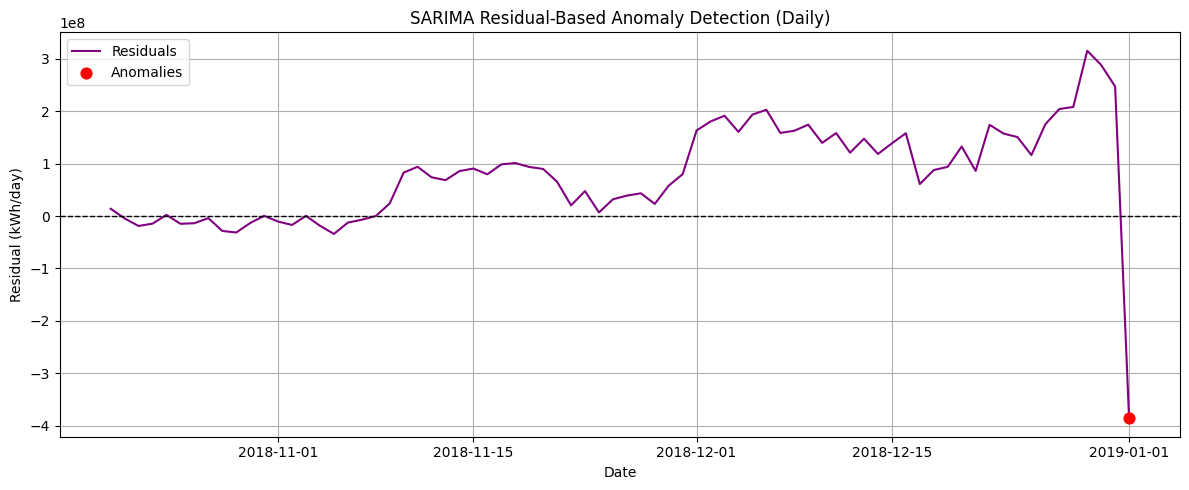

Peak-day SARIMA anomalies: 0


In [ ]:
# Residuals over time
plt.figure(figsize=(12, 5))
plt.plot(sarima_results_df.index, sarima_results_df["residual"], color="purple")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Residuals of the SARIMA Forecast (Daily)")
plt.xlabel("Date")
plt.ylabel("Residual (kWh/day)")
plt.tight_layout()
plt.show()

# Residual distribution
plt.figure(figsize=(8, 4))
plt.hist(sarima_results_df["residual"], bins=30, color="steelblue", edgecolor="black")
plt.title("Distribution of SARIMA Residuals (Daily)")
plt.xlabel("Residual (kWh/day)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Z-score anomaly detection
s_mean = sarima_results_df["residual"].mean()
s_std  = sarima_results_df["residual"].std()
sarima_results_df["z_score"]   = (sarima_results_df["residual"] - s_mean) / s_std
sarima_results_df["is_anomaly"] = sarima_results_df["z_score"].abs() > 3

sanomalies_df = sarima_results_df[sarima_results_df["is_anomaly"]]
print(f"Total SARIMA anomalies detected: {len(sanomalies_df)}")
if len(sanomalies_df) > 0:
    print(sanomalies_df[["actual","forecast","residual","z_score"]])

# Anomaly plot
plt.figure(figsize=(12, 5))
plt.plot(sarima_results_df.index, sarima_results_df["residual"], label="Residuals", color="purple")
plt.scatter(sanomalies_df.index, sanomalies_df["residual"], color="red", label="Anomalies", zorder=5, s=60)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("SARIMA Residual-Based Anomaly Detection (Daily)")
plt.xlabel("Date")
plt.ylabel("Residual (kWh/day)")
plt.legend()
plt.tight_layout()
plt.show()

# Peak-day anomalies
sarima_peak_anomalies_df = sanomalies_df[sanomalies_df.index.dayofweek.isin(peak_dow_list)]
print(f"Peak-day SARIMA anomalies: {len(sarima_peak_anomalies_df)}")


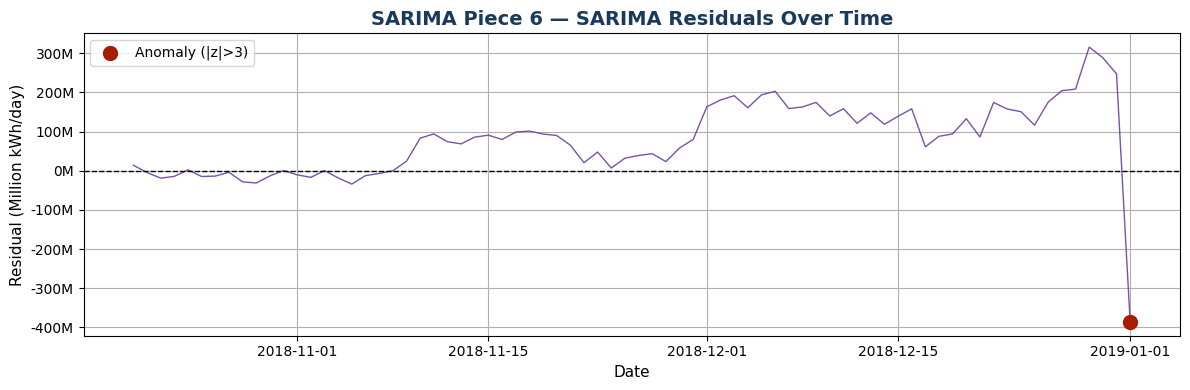

Saved: s6_sarima_residuals.png


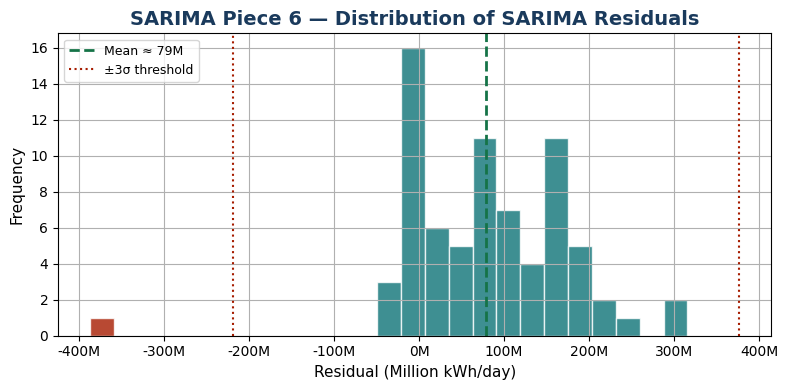

Saved: s6_sarima_hist.png


In [ ]:

# ── Save SARIMA Piece 6 charts ───────────────────────────────────────────────
sarima_resid = sarima_results_df['residual']
mean_sr  = sarima_resid.mean()
std_sr   = sarima_resid.std()

# Chart 1: SARIMA residuals over time
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sarima_resid.index, sarima_resid/1e6, color='#6B3FA0', linewidth=1.0, alpha=0.9)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
sarima_anom_mask = sanomalies_df.index
ax.scatter(sarima_anom_mask, sarima_resid[sarima_anom_mask]/1e6,
           color='#A61C00', s=100, zorder=5, label='Anomaly (|z|>3)')
ax.set_title('SARIMA Piece 6 — SARIMA Residuals Over Time', fontsize=14, fontweight='bold', color='#1A3A5C')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Residual (Million kWh/day)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('s6_sarima_residuals.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: s6_sarima_residuals.png")

# Chart 2: SARIMA residual histogram
fig, ax = plt.subplots(figsize=(8, 4))
n, bins, patches = ax.hist(sarima_resid/1e6, bins=25, color='#0D7377', edgecolor='white', alpha=0.8)
for patch, left in zip(patches, bins[:-1]):
    if abs((left*1e6 - mean_sr) / std_sr) > 3:
        patch.set_facecolor('#A61C00')
ax.axvline(mean_sr/1e6, color='#157347', linewidth=2, linestyle='--', label=f'Mean ≈ {mean_sr/1e6:.0f}M')
ax.axvline((mean_sr+3*std_sr)/1e6, color='#A61C00', linewidth=1.5, linestyle=':', label='±3σ threshold')
ax.axvline((mean_sr-3*std_sr)/1e6, color='#A61C00', linewidth=1.5, linestyle=':')
ax.set_title('SARIMA Piece 6 — Distribution of SARIMA Residuals', fontsize=14, fontweight='bold', color='#1A3A5C')
ax.set_xlabel('Residual (Million kWh/day)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('s6_sarima_hist.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: s6_sarima_hist.png")


## SARIMA — Piece 6B: Ljung–Box residual autocorrelation test

In [ ]:
# Use lag=7 because the data are daily and one weekly cycle = 7 days
sarima_lb = acorr_ljungbox(sarima_results_df["residual"].dropna(), lags=[7], return_df=True)

sarima_lb_stat = sarima_lb["lb_stat"].iloc[0]
sarima_lb_p = sarima_lb["lb_pvalue"].iloc[0]

print("SARIMA Ljung–Box Test (lag=7, daily data)")
print(sarima_lb.to_string())
print(f"\nSARIMA p-value = {sarima_lb_p:.4f} → " +
      ("no significant autocorrelation remains" if sarima_lb_p > 0.05 else "significant autocorrelation remains"))


SARIMA Ljung–Box Test (lag=7, daily data)
    lb_stat     lb_pvalue
7  70.63463  1.099552e-12

SARIMA p-value = 0.0000 → significant autocorrelation remains


## Piece 8 — Final comparison: ARIMA vs SARIMA (Daily)

## Piece 8 — Final comparison: ARIMA vs SARIMA (Daily)

In [ ]:
# ── Performance metrics table ───────────────────────────────────────────────
comparison_metrics = pd.DataFrame({
    "Metric":           ["MAE (kWh/day)", "RMSE (kWh/day)", "MAPE (%)", "R²"],
    "ARIMA_Overall":    [mae,              rmse,              mape,        r2],
    "SARIMA_Overall":   [sarima_mae,       sarima_rmse,       sarima_mape, sarima_r2],
    "ARIMA_Peak_Day":   [peak_mae,         peak_rmse,         peak_mape,   peak_r2],
    "SARIMA_Peak_Day":  [sarima_peak_mae,  sarima_peak_rmse,  sarima_peak_mape, sarima_peak_r2],
})

print("\nARIMA vs SARIMA — Performance Comparison (Daily)")
print("=" * 65)
print(comparison_metrics.to_string(index=False))

# ── Anomaly comparison table ────────────────────────────────────────────────
comparison_anomalies = pd.DataFrame({
    "Category":          ["Total anomalies", "Peak-day anomalies"],
    "ARIMA":             [len(anomalies_df), len(peak_anomalies_df)],
    "SARIMA":            [len(sanomalies_df), len(sarima_peak_anomalies_df)],
})

print("\nARIMA vs SARIMA — Anomaly Comparison (Daily)")
print("=" * 45)
print(comparison_anomalies.to_string(index=False))

# ── Ljung–Box comparison table (reported here; tested earlier in diagnostics) ──
ljung_box_comparison = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA"],
    "Lag": [7, 7],
    "Ljung_Box_Statistic": [arima_lb_stat, sarima_lb_stat],
    "p_value": [arima_lb_p, sarima_lb_p],
    "Residual_Autocorrelation": [
        "No significant autocorrelation" if arima_lb_p > 0.05 else "Significant autocorrelation remains",
        "No significant autocorrelation" if sarima_lb_p > 0.05 else "Significant autocorrelation remains"
    ]
})

print("\nARIMA vs SARIMA — Ljung–Box Comparison (Daily)")
print("=" * 60)
print(ljung_box_comparison.to_string(index=False))

# ── Winner per metric ─────────────────────────────────────────────────────────
def winner_lower(a, b):  return "SARIMA" if b < a else ("ARIMA" if a < b else "Equal")
def winner_higher(a, b): return "SARIMA" if b > a else ("ARIMA" if a > b else "Equal")

print("\nBest model by metric:")
print(f"  Overall MAE    : {winner_lower(mae,        sarima_mae)}")
print(f"  Overall RMSE   : {winner_lower(rmse,       sarima_rmse)}")
print(f"  Overall MAPE   : {winner_lower(mape,       sarima_mape)}")
print(f"  Overall R²     : {winner_higher(r2,        sarima_r2)}")
print(f"  Peak-day MAE   : {winner_lower(peak_mae,   sarima_peak_mae)}")
print(f"  Peak-day RMSE  : {winner_lower(peak_rmse,  sarima_peak_rmse)}")
print(f"  Peak-day MAPE  : {winner_lower(peak_mape,  sarima_peak_mape)}")
print(f"  Peak-day R²    : {winner_higher(peak_r2,   sarima_peak_r2)}")
print(f"  Ljung–Box p-value : {'SARIMA' if sarima_lb_p > arima_lb_p else 'ARIMA'}")

# ── Save ──────────────────────────────────────────────────────────────────────
comparison_metrics.to_csv("arima_vs_sarima_daily_metrics.csv", index=False)
comparison_anomalies.to_csv("arima_vs_sarima_daily_anomalies.csv", index=False)
ljung_box_comparison.to_csv("ljung_box_daily_comparison.csv", index=False)
print("\nSaved: arima_vs_sarima_daily_metrics.csv")
print("Saved: arima_vs_sarima_daily_anomalies.csv")
print("Saved: ljung_box_daily_comparison.csv")



ARIMA vs SARIMA — Performance Comparison (Daily)
        Metric  ARIMA_Overall  SARIMA_Overall  ARIMA_Peak_Day  SARIMA_Peak_Day
 MAE (kWh/day)   1.192979e+08    9.610462e+07    1.303048e+08     1.054112e+08
RMSE (kWh/day)   1.523783e+08    1.262026e+08    1.655273e+08     1.346101e+08
      MAPE (%)   8.144836e+01    8.687365e+01    2.456861e+01     1.995106e+01
            R²  -9.311630e-01   -3.246755e-01   -1.284422e+00    -5.107496e-01

ARIMA vs SARIMA — Anomaly Comparison (Daily)
          Category  ARIMA  SARIMA
   Total anomalies      1       1
Peak-day anomalies      0       0

ARIMA vs SARIMA — Ljung–Box Comparison (Daily)
 Model  Lag  Ljung_Box_Statistic      p_value            Residual_Autocorrelation
 ARIMA    7           118.824975 1.345703e-22 Significant autocorrelation remains
SARIMA    7            70.634630 1.099552e-12 Significant autocorrelation remains

Best model by metric:
  Overall MAE    : SARIMA
  Overall RMSE   : SARIMA
  Overall MAPE   : ARIMA
  Overall R² 

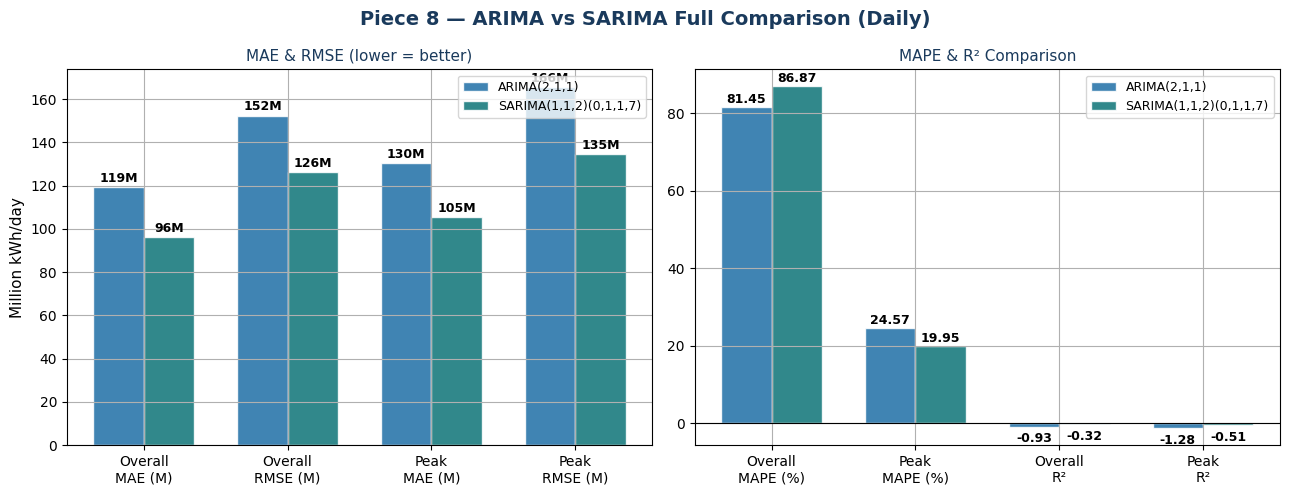

Saved: p8_comparison.png


In [ ]:

# ── Save Piece 8 comparison chart ───────────────────────────────────────────
import numpy as np
metrics_lbl = ['Overall\nMAE (M)', 'Overall\nRMSE (M)', 'Peak\nMAE (M)', 'Peak\nRMSE (M)']
arima_vals  = [mae/1e6, rmse/1e6, peak_mae/1e6, peak_rmse/1e6]
sarima_vals = [sarima_mae/1e6, sarima_rmse/1e6, sarima_peak_mae/1e6, sarima_peak_rmse/1e6]
x = np.arange(len(metrics_lbl)); w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Piece 8 — ARIMA vs SARIMA Full Comparison (Daily)', fontsize=14, fontweight='bold', color='#1A3A5C')

# Left: MAE & RMSE
b1 = axes[0].bar(x-w/2, arima_vals,  w, label='ARIMA(2,1,1)',            color='#1E6FA6', alpha=0.85, edgecolor='white')
b2 = axes[0].bar(x+w/2, sarima_vals, w, label='SARIMA(1,1,2)(0,1,1,7)', color='#0D7377', alpha=0.85, edgecolor='white')
for bar, val in zip(list(b1)+list(b2), arima_vals+sarima_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.0f}M',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics_lbl, fontsize=10)
axes[0].set_ylabel('Million kWh/day', fontsize=11)
axes[0].set_title('MAE & RMSE (lower = better)', fontsize=11, color='#1A3A5C')
axes[0].legend(fontsize=9)

# Right: MAPE & R²
mets2    = ['Overall\nMAPE (%)', 'Peak\nMAPE (%)', 'Overall\nR²', 'Peak\nR²']
arima_v2 = [mape, peak_mape, r2, peak_r2]
sar_v2   = [sarima_mape, sarima_peak_mape, sarima_r2, sarima_peak_r2]
x2 = np.arange(len(mets2))
b3 = axes[1].bar(x2-w/2, arima_v2, w, label='ARIMA(2,1,1)',            color='#1E6FA6', alpha=0.85, edgecolor='white')
b4 = axes[1].bar(x2+w/2, sar_v2,   w, label='SARIMA(1,1,2)(0,1,1,7)', color='#0D7377', alpha=0.85, edgecolor='white')
for bar, val in zip(list(b3)+list(b4), arima_v2+sar_v2):
    offset = 0.3 if val >= 0 else -1.5
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+offset,
                 f'{val:.2f}', ha='center', va='bottom' if val>=0 else 'top',
                 fontsize=9, fontweight='bold')
axes[1].set_xticks(x2); axes[1].set_xticklabels(mets2, fontsize=10)
axes[1].set_title('MAPE & R² Comparison', fontsize=11, color='#1A3A5C')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig('p8_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: p8_comparison.png")


## Download all charts as a ZIP file

In [ ]:

# ── Zip all charts for easy download ────────────────────────────────────────
import zipfile, os
chart_files = [f for f in os.listdir('.') if f.endswith('.png')]
with zipfile.ZipFile('daily_charts.zip', 'w') as zf:
    for f in sorted(chart_files):
        zf.write(f)
        print(f'  Added: {f}')
print(f'\nDone! daily_charts.zip contains {len(chart_files)} charts.')
print('Download it from the Colab Files panel on the left sidebar.')


  Added: p1_daily_series.png
  Added: p2_dow_pattern.png
  Added: p2_monthly_pattern.png
  Added: p2_rolling_avg.png
  Added: p3_decomposition.png
  Added: p4_stationarity.png
  Added: p5_acf_pacf.png
  Added: p6_arima_forecast.png
  Added: p6_arima_peak_forecast.png
  Added: p7_hist.png
  Added: p7_residuals.png
  Added: p8_comparison.png
  Added: s2_seasonal_diff.png
  Added: s3_sarima_acf_pacf.png
  Added: s5_sarima_forecast.png
  Added: s5_sarima_peak_forecast.png
  Added: s6_sarima_hist.png
  Added: s6_sarima_residuals.png

Done! daily_charts.zip contains 18 charts.
Download it from the Colab Files panel on the left sidebar.
